In [705]:
import matplotlib.pyplot as plt
import matplotlib.pylab as pl 
import matplotlib    
import json
import tqdm
matplotlib.rcParams.update({"font.size": 12})                                                                                                                                           
matplotlib.rcParams["mathtext.fontset"] = "cm"                                                                                                                                          
plt.rcParams["font.family"] = "Serif"  

import numpy as np
import numpy.typing as npt
from numba import config, njit, prange, get_thread_id
import numba
import matplotlib.pyplot as plt

from pysco.laplacian import jacobi, jacobi_w, gauss_seidel, initialise_potential, residual_error, residual, restrict_residual
from pysco.laplacian import exact_coarse_solve, block_jacobi, block_jacobi_w, compute_Ainv, smoothing_block_jacobi_w, smoothing_block_jacobi, compute_A_periodic, compute_Ainv_periodic
from pysco.laplacian import chebyshev_form1,chebyshev_coeffs, chebyshev_coeffs_lottes, chebyshev_form1_opt
from pysco.laplacian import smoothing_jacobi, smoothing_jacobi_w, smoothing_gs, smoothing_chebyshev1, smoothing_chebyshev4
from pysco.laplacian import smoothing_chebyshev4_opt
from pysco.multigrid import V_cycle
from pysco.mesh import add_prolongation
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [673]:
def gamma_tabular(n_smoothing):
    if n_smoothing == 1:
        return np.array([1.12500000000000]).astype(np.float32)
    elif n_smoothing == 2:
        return np.array([1.02387287570313, 1.26408905371085]).astype(np.float32)
    elif n_smoothing == 3:
        return np.array([1.00842544782028, 1.08867839208730, 1.33753125909618]).astype(np.float32)
    elif n_smoothing == 4:
        return np.array([1.00391310427285, 1.04035811188593,1.14863498546254,1.38268869241000]).astype(np.float32)
    elif n_smoothing == 5:
        return np.array([1.00212930146164, 1.02173711549260,1.07872433192603,1.19810065292663,1.41322542791682]).astype(np.float32)
    elif n_smoothing == 6:
        return np.array([1.00128517255940,1.01304293035233,1.04678215124113,1.11616489419675,1.23829020218444,1.43524297106744]).astype(np.float32)
    elif n_smoothing == 7:
        return np.array([1.00083464397912,1.00843949430122,1.03008707768713,1.07408384092003,1.15036186707366,
1.27116474046139,1.45186658649364]).astype(np.float32)
    elif n_smoothing == 8:
        return np.array([1.00057246631197,1.00577427662415,1.02050187922941,1.05019803444565,1.10115572984941,
1.18086042806856,1.29838585382576,1.46486073151099]).astype(np.float32)
    elif n_smoothing == 9:
        return np.array([1.00040960072832,1.00412439506106,1.01460212148266,1.03561113626671,1.07139972529194,
1.12688273710962,1.20785219140729,1.32121930716746,1.47529642820699]).astype(np.float32)
    elif n_smoothing == 10:
        return np.array([1.00030312229652,1.00304840660796,
1.01077022715387,
1.02619011597640,
1.05231724933755,
1.09255743207549,
1.15083376663972,
1.23172250870894,
1.34060802024460,
1.48386124407011]).astype(np.float32)
    

# Set number of threads

In [674]:
numba.set_num_threads(1)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [675]:
# Image resolution
#dpi = 10 # bad resolution
dpi=300 # good resolution

# Grid resolution, number of iterations
# Initial conditions: either point mass or random

In [676]:
# Constants                                                                                                                                                                             
PI = np.pi                                                                                                                                                                              
G = 1.0 / (4 * PI)                                                                                                                                                                      
rho0 = 1.0                                                                                                                                                                              
r0 = 0.01                                                                                                                                                                         
L = 1.0                                                                                                                                                                                 
M = 2 * PI * r0**3 * rho0                                                                                                                                                               
                                                                                                                                                                                        
@njit
def rho(r2):
    r = np.sqrt(r2) * L
    return rho0 / ((r / r0) * (1 + r / r0)**3) 

@njit(parallel=True)
def initialise_rho(ncells1d):
    rho_arr = np.zeros((ncells1d, ncells1d, ncells1d), dtype=np.float32)
    h = np.float32(1./ncells1d)
    for i in range(ncells1d):
        for j in range(ncells1d):
            for k in range(ncells1d):
                r2 = ( (i+0.5)*h - 0.5)**2 + ( (j+0.5)*h - 0.5)**2 + ( (k+0.5)*h - 0.5)**2
                rho_arr[i,j,k] = rho(r2)
    return rho_arr


In [677]:
def max_condition(param):
    return (param["ncoarse"] - 3)
    #return 0
def V_cycle_jacobi(x, b, param, nlevel = 0) -> None:
    smoothing_jacobi(x, b, param["Npre"])
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        exact_coarse_solve(x_corr_c, res_c)
        #smoothing_jacobi(x_corr_c, res_c, param["Npre"])
    else:
        V_cycle_jacobi(x_corr_c, res_c, param, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_jacobi(x, b, param["Npost"])

def V_cycle_jacobi_w(x, b, param, w, nlevel = 0) -> None:
    smoothing_jacobi_w(x, b, param["Npre"], w)
    res_c = restrict_residual(x, b)
    x_corr_c = w*initialise_potential(res_c)
    if nlevel >= max_condition(param):
        exact_coarse_solve(x_corr_c, res_c)
        #smoothing_jacobi_w(x_corr_c, res_c, param["Npre"], w)
    else:
        V_cycle_jacobi_w(x_corr_c, res_c, param, w, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_jacobi_w(x, b, param["Npost"], w)

def V_cycle_jacobi_w1w2(x, b, param, w1,w2, nlevel = 0) -> None:
    smoothing_jacobi_w(x, b, param["Npre"], w1)
    res_c = restrict_residual(x, b)
    x_corr_c = w1*initialise_potential(res_c)
    if nlevel >= max_condition(param):
        exact_coarse_solve(x_corr_c, res_c)
        #smoothing_jacobi_w(x_corr_c, res_c, param["Npre"], w1)
    else:
        V_cycle_jacobi_w1w2(x_corr_c, res_c, param, w1,w2, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_jacobi_w(x, b, param["Npost"], w2)

def V_cycle_block_jacobi(x, b, param, blocksize, nlevel = 0) -> None:
    smoothing_block_jacobi(x, b, param["Npre"], blocksize)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        exact_coarse_solve(x_corr_c, res_c)
    else:
        V_cycle_block_jacobi(x_corr_c, res_c, param, blocksize, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_block_jacobi(x, b, param["Npost"], blocksize)

def V_cycle_block_jacobi_w(x, b, param, blocksize, w, nlevel = 0) -> None:
    smoothing_block_jacobi_w(x, b, param["Npre"], blocksize, w)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        exact_coarse_solve(x_corr_c, res_c)
    else:
        V_cycle_block_jacobi_w(x_corr_c, res_c, param, blocksize, w, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_block_jacobi_w(x, b, param["Npost"], blocksize, w)
    
def V_cycle_jacobi_gs(x, b, param, w1,w2, nlevel = 0) -> None:
    smoothing_jacobi_w(x, b, param["Npre"], w1)
    res_c = restrict_residual(x, b)
    x_corr_c = w1*initialise_potential(res_c)
    if nlevel >= max_condition(param):
        exact_coarse_solve(x_corr_c, res_c)
        #smoothing_jacobi_w(x_corr_c, res_c, param["Npre"], w1)
    else:
        V_cycle_jacobi_gs(x_corr_c, res_c, param, w1,w2, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_gs(x, b, param["Npost"], w2)

def V_cycle_gs_jacobi(x, b, param, w1,w2, nlevel = 0) -> None:
    smoothing_gs(x, b, param["Npre"], w1)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        exact_coarse_solve(x_corr_c, res_c)
        #smoothing_gs(x_corr_c, res_c, param["Npre"], w1)
    else:
        V_cycle_gs_jacobi(x_corr_c, res_c, param, w1,w2, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_jacobi_w(x, b, param["Npost"], w2)

def V_cycle_gs(x, b, param, f_relax, nlevel = 0) -> None:
    smoothing_gs(x, b, param["Npre"], f_relax)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        exact_coarse_solve(x_corr_c, res_c)
        #smoothing_gs(x_corr_c, res_c, param["Npre"], f_relax)
    else:
        V_cycle_gs(x_corr_c, res_c, param, f_relax, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_gs(x, b, param["Npost"], f_relax)

def V_cycle_gs_w1w2(x, b, param, w1,w2, nlevel = 0) -> None:
    smoothing_gs(x, b, param["Npre"], w1)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        exact_coarse_solve(x_corr_c, res_c)
        #smoothing_gs(x_corr_c, res_c, param["Npre"], w1)
    else:
        V_cycle_gs_w1w2(x_corr_c, res_c, param, w1,w2, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_gs(x, b, param["Npost"], w2)

def V_cycle_chebyshev1(x, b, param, lambda_min, lambda_max, nlevel = 0) -> None:
    smoothing_chebyshev1(x, b, param["Npre"], lambda_min, lambda_max)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        exact_coarse_solve(x_corr_c, res_c)
        #smoothing_chebyshev1(x_corr_c, res_c, param["Npre"], lambda_min, lambda_max)
    else:
        V_cycle_chebyshev1(x_corr_c, res_c, param, lambda_min, lambda_max, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_chebyshev1(x, b, param["Npost"], lambda_min, lambda_max)

def V_cycle_chebyshev1_jacobi(x, b, param, lambda_min, lambda_max, w, nlevel = 0) -> None:
    smoothing_chebyshev1(x, b, param["Npre"], lambda_min, lambda_max)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        exact_coarse_solve(x_corr_c, res_c)
        #smoothing_chebyshev1(x_corr_c, res_c, param["Npre"], lambda_min, lambda_max)
    else:
        V_cycle_chebyshev1_jacobi(x_corr_c, res_c, param, lambda_min, lambda_max, w, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_jacobi_w(x, b, param["Npost"], w)

def V_cycle_chebyshev1_gs(x, b, param, lambda_min, lambda_max, w, nlevel = 0) -> None:
    smoothing_chebyshev1(x, b, param["Npre"], lambda_min, lambda_max)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        exact_coarse_solve(x_corr_c, res_c)
        #smoothing_chebyshev1(x_corr_c, res_c, param["Npre"], lambda_min, lambda_max)
    else:
        V_cycle_chebyshev1_gs(x_corr_c, res_c, param, lambda_min, lambda_max, w, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_gs(x, b, param["Npost"], w)

def V_cycle_chebyshev4(x, b, param, lambda_max, nlevel = 0) -> None:
    smoothing_chebyshev4(x, b, param["Npre"], lambda_max)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        exact_coarse_solve(x_corr_c, res_c)
        #smoothing_chebyshev4(x_corr_c, res_c, param["Npre"], lambda_max)
    else:
        V_cycle_chebyshev4(x_corr_c, res_c, param, lambda_max, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_chebyshev4(x, b, param["Npost"], lambda_max)

def V_cycle_chebyshev4_opt(x, b, param, lambda_max, nlevel = 0) -> None:
    smoothing_chebyshev4_opt(x, b, param["Npre"], lambda_max)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        exact_coarse_solve(x_corr_c, res_c)
        #smoothing_chebyshev4(x_corr_c, res_c, param["Npre"], lambda_max)
    else:
        V_cycle_chebyshev4(x_corr_c, res_c, param, lambda_max, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_chebyshev4_opt(x, b, param["Npost"], lambda_max)

def V_cycle_chebyshev4_jacobi(x, b, param, lambda_max, w, nlevel = 0) -> None:
    smoothing_chebyshev4(x, b, param["Npre"], lambda_max)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        exact_coarse_solve(x_corr_c, res_c)
        #smoothing_chebyshev4(x_corr_c, res_c, param["Npre"], lambda_max)
    else:
        V_cycle_chebyshev4_jacobi(x_corr_c, res_c, param, lambda_max, w, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_jacobi_w(x, b, param["Npost"], w)

def V_cycle_chebyshev4_gs(x, b, param, lambda_max, w, nlevel = 0) -> None:
    smoothing_chebyshev4(x, b, param["Npre"], lambda_max)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        exact_coarse_solve(x_corr_c, res_c)
        #smoothing_chebyshev4(x_corr_c, res_c, param["Npre"], lambda_max)
    else:
        V_cycle_chebyshev4_gs(x_corr_c, res_c, param, lambda_max, w, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_gs(x, b, param["Npost"], w)

def V_cycle_chebyshev4_opt_jacobi(x, b, param, lambda_max, w, nlevel = 0) -> None:
    smoothing_chebyshev4_opt(x, b, param["Npre"], lambda_max)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        exact_coarse_solve(x_corr_c, res_c)
        #smoothing_chebyshev4_opt(x_corr_c, res_c, param["Npre"], lambda_max)
    else:
        V_cycle_chebyshev4_jacobi(x_corr_c, res_c, param, lambda_max, w, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_jacobi_w(x, b, param["Npost"], w)

def V_cycle_chebyshev4_opt_gs(x, b, param, lambda_max, w, nlevel = 0) -> None:
    smoothing_chebyshev4_opt(x, b, param["Npre"], lambda_max)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        exact_coarse_solve(x_corr_c, res_c)
        #smoothing_chebyshev4_opt(x_corr_c, res_c, param["Npre"], lambda_max)
    else:
        V_cycle_chebyshev4_gs(x_corr_c, res_c, param, lambda_max, w, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_gs(x, b, param["Npost"], w)


In [678]:
nsmooth=10 # Must be even, or with ping-pong new/old the value is not where it should
n = 32
source = "hernquist"
#source = "random

In [679]:
if source == "hernquist":
    b = initialise_rho(n)
elif source == "random":
    b = np.random.rand(n,n,n).astype(np.float32)
else:
    raise ValueError(f"{source=}, should be 'hernquist' or 'random'")
#b.fill(0)
#b[0,n//2,n//2] = 1
b -= np.mean(b)
x0 = np.zeros_like(b)
initialise_potential(x0)
tmp = np.empty_like(x0)
print(f"{np.mean(b)=}")

np.mean(b)=np.float32(1.1368684e-13)


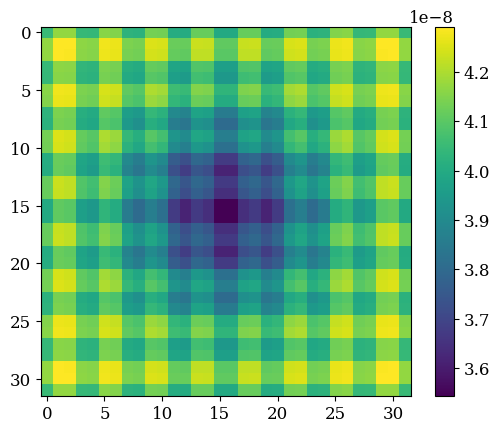

0.0017640356672927737


In [680]:
x00 = np.zeros_like(b)
tmp = np.zeros_like(b)
Ainv = compute_Ainv(4)
for _ in range(20):
    block_jacobi_w(tmp, x00, b, Ainv, 0.9)
    tmp, x00 = x00, tmp
plt.imshow(tmp[0])
plt.colorbar()
plt.show()

print(residual_error(tmp, b))

## Density term

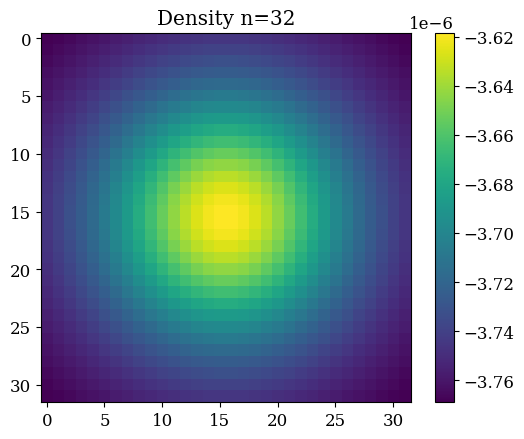

In [681]:
fig, ax = plt.subplots()
im=ax.imshow(b[0])
fig.colorbar(im, ax=ax)
ax.set_title(f'Density {n=}')
path="/local/home/mb280636/data/Dyablo/smoothers/pysco_tests"
fig.savefig(f"{path}/full_comparison/density_{source}.png", bbox_inches="tight", dpi=dpi)
plt.show()
plt.close(fig)
del fig, ax

In [682]:
r0 = residual(x0,b)
re0 = residual_error(x0,b)
print(re0, x0[n//2,n//2,n//2], b[n//2,n//2,n//2])

0.020999358966946602 0.0 0.0072537162


# Compute residual on each iteration for the following smoothers:
    Jacobi, Jacobi (weighted), Gauss-Seidel, GS (weighted/SOR), Chebyshev (1st kind), Lottes Chebyshev (4th kind)

In [683]:
# Jacobi
xj = x0.copy()
rj = np.empty(nsmooth+1)
rj[0] = re0
for i in range(nsmooth):
    jacobi(tmp, xj,b)
    tmp, xj = xj, tmp
    rj[i+1] = residual_error(xj,b)

In [684]:
# Jacobi Weighted
xjw = x0.copy()
rjw = np.empty(nsmooth+1)
rjw[0] = re0
w = np.float32(0.9)
for i in range(nsmooth):
    jacobi_w(tmp, xjw, b, w)
    tmp, xjw = xjw, tmp
    rjw[i+1] = residual_error(xjw,b)

In [685]:
# Block Jacobi 2
Ainv2 = compute_Ainv(2)
xbj2 = x0.copy()
rbj2 = np.empty(nsmooth+1)
rbj2[0] = re0
for i in range(nsmooth):
    block_jacobi(tmp, xbj2,b, Ainv2)
    tmp, xbj2 = xbj2, tmp
    rbj2[i+1] = residual_error(xbj2,b)

In [686]:
# Block Jacobi 2
Ainv2 = compute_Ainv(2)
xbj2w = x0.copy()
rbj2w = np.empty(nsmooth+1)
rbj2w[0] = re0
for i in range(nsmooth):
    block_jacobi_w(tmp, xbj2w, b, Ainv2, 1.2)
    tmp, xbj2w = xbj2w, tmp
    rbj2w[i+1] = residual_error(xbj2w,b)

In [687]:
# Block Jacobi 4
Ainv4 = compute_Ainv(4)
xbj4 = x0.copy()
rbj4 = np.empty(nsmooth+1)
rbj4[0] = re0
for i in range(nsmooth):
    block_jacobi(tmp, xbj4,b, Ainv4)
    tmp, xbj4 = xbj4, tmp
    rbj4[i+1] = residual_error(xbj4,b)

In [688]:
# Block Jacobi 4
Ainv4 = compute_Ainv(4)
xbj4w = x0.copy()
rbj4w = np.empty(nsmooth+1)
rbj4w[0] = re0
for i in range(nsmooth):
    block_jacobi_w(tmp, xbj4w, b, Ainv4, 1.2)
    tmp, xbj4w = xbj4w, tmp
    rbj4w[i+1] = residual_error(xbj4w,b)

In [689]:
# Gauss-Seidel
xg0 = x0.copy()
rg0 = np.empty(nsmooth+1)
f_relax0 = np.float32(1.)
rg0[0] = re0
for i in range(nsmooth):
    gauss_seidel(xg0,b, f_relax0)
    rg0[i+1] = residual_error(xg0,b)

In [690]:
# Gauss-Seidel with SOR
xg = x0.copy()
rg = np.empty(nsmooth+1)
f_relax = np.float32(1.25)
rg[0] = re0
for i in range(nsmooth):
    gauss_seidel(xg,b, f_relax)
    rg[i+1] = residual_error(xg,b)

In [691]:
# Standard 1st-kind Chebyshev
xc = x0.copy()
rc = np.empty(nsmooth+1)
rc[0] = re0
h = np.float32(1./x0.shape[0])
Dm1 = np.float32(-h*h/6.)
rr = r0.copy()
# --- eigenvalue estimates (3D Poisson) ---
ncells_1d = xc.shape[0]
h2 = np.float32(1.0 / ncells_1d**2)
lambda_max = np.float32(2.)
lambda_min = np.float32(0.1) * lambda_max
theta = np.float32(0.5) * (lambda_max + lambda_min)
delta = np.float32(0.5) * (lambda_max - lambda_min)
#----- RUn
alpha, beta = chebyshev_coeffs(nsmooth, theta, delta)
z = alpha[0]*Dm1*rr
for k in range(nsmooth):
    chebyshev_form1(xc, tmp, z, rr, alpha[k+1], beta[k+1])
    z, tmp = tmp, z
    rc[k+1] = residual_error(xc,b)

In [692]:
# Lottes Chebyshev of 4th kind
xcl = x0.copy()
rcl = np.empty(nsmooth+1)
rcl[0] = re0
h = np.float32(1./x0.shape[0])
Dm1 = np.float32(-h*h/6.)
# --- eigenvalue estimates (3D Poisson) ---
ncells_1d = xcl.shape[0]
h2 = np.float32(1.0 / ncells_1d**2)
lambda_max = np.float32(2.)
nu = np.float32(4/lambda_max)
#----- Run
alpha, beta = chebyshev_coeffs_lottes(nsmooth, nu)
rr = r0.copy()
z = alpha[0]*Dm1*rr
for k in range(nsmooth):
    chebyshev_form1(xcl, tmp, z, rr, alpha[k+1], beta[k+1])
    tmp, z = z, tmp
    rcl[k+1] = residual_error(xcl,b)

In [693]:
# Lottes Chebyshev of 4th kind Optimised
xclo = x0.copy()
rclo = np.empty(nsmooth+1)
rclo[0] = re0
h = np.float32(1./x0.shape[0])
Dm1 = np.float32(-h*h/6.)
# --- eigenvalue estimates (3D Poisson) ---
ncells_1d = xclo.shape[0]
h2 = np.float32(1.0 / ncells_1d**2)
lambda_max = np.float32(2.)
nu = np.float32(4/lambda_max)
#----- Run
alpha, beta = chebyshev_coeffs_lottes(nsmooth, nu)
gamma = gamma_tabular(nsmooth)
rr = r0.copy()
z = alpha[0]*Dm1*rr
for k in range(nsmooth):
    chebyshev_form1_opt(xclo, tmp, z, rr, alpha[k+1], beta[k+1], gamma[k])
    tmp, z = z, tmp
    rclo[k+1] = residual_error(xclo,b)

## Compute final residual for the pysco smoother utility

In [695]:
label_jacobi="Jacobi"
label_jacobi_w=f"Jacobi (w = {w:.2f})"
label_block_jacobi2=f"Block Jacobi (bx = {2})"
label_block_jacobi4=f"Block Jacobi (bx = {4})"
label_block_jacobi2w=f"Block Jacobi (bx = {2}, w=1.1)"
label_block_jacobi4w=f"Block Jacobi (bx = {4}, w=1.1)"
label_gs0="Gauss-Seidel"
label_gs=f"Gauss-Seidel (w = {f_relax:.2f})"
label_c="Chebyshev"
label_cl="Chebyshev Lottes"
label_clo="Chebyshev Lottes Opt"

## Plot residual per iteration for all smoothers

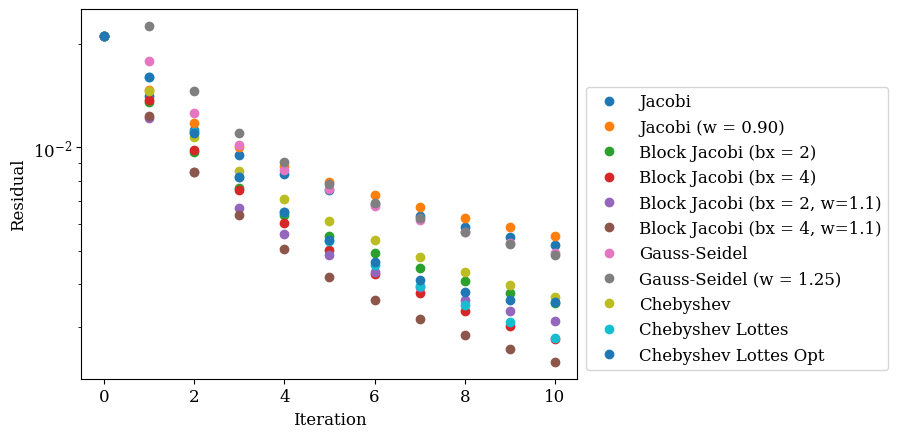

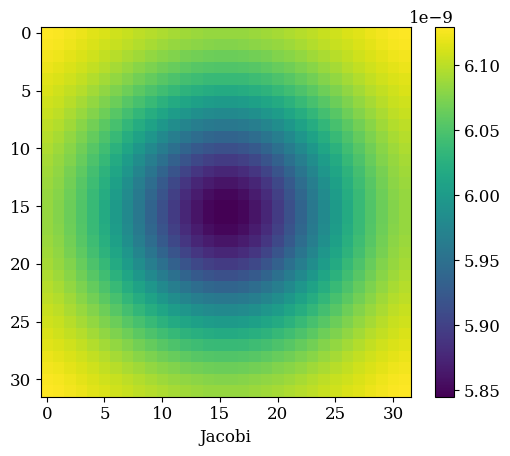

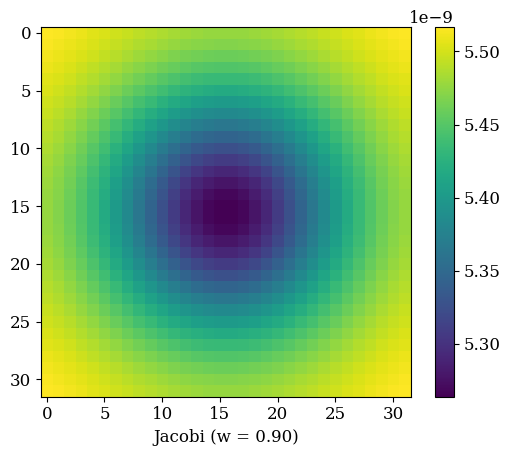

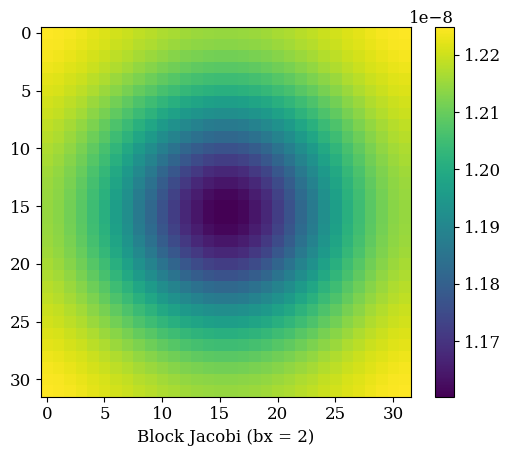

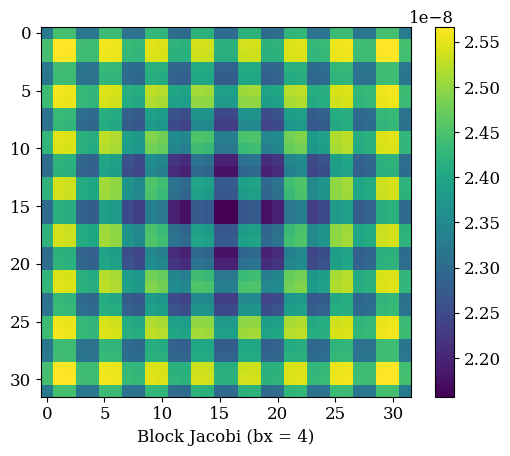

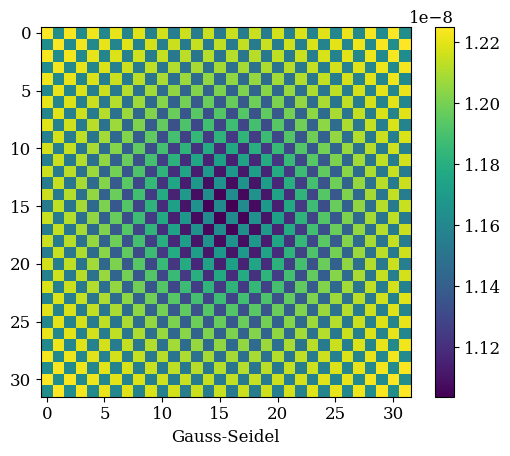

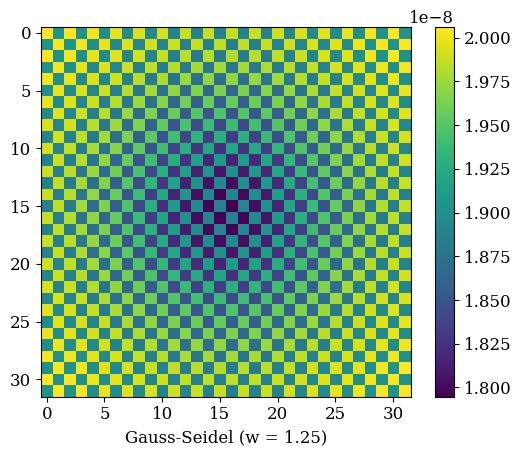

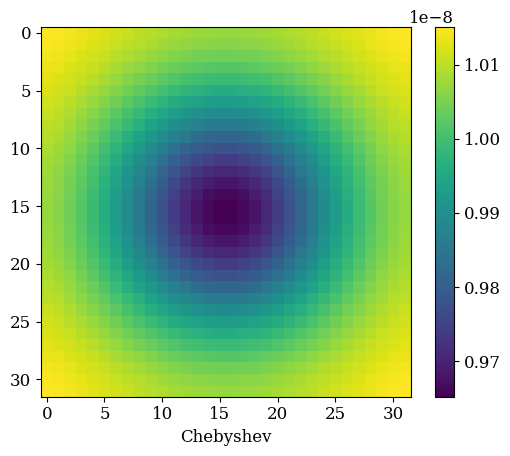

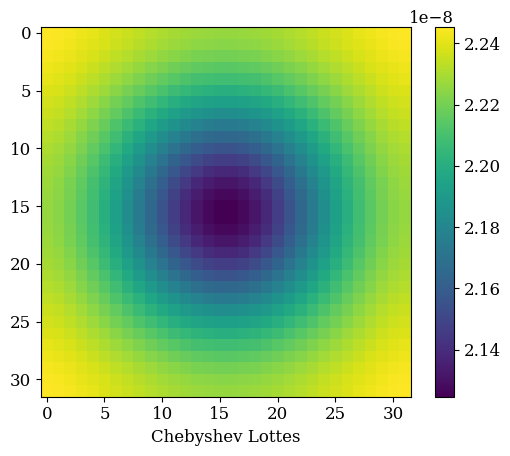

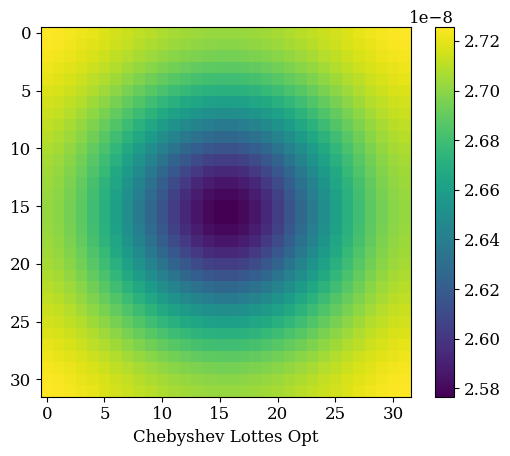

In [697]:
fig, ax = plt.subplots()
ax.semilogy(rj, "o", label=label_jacobi)
ax.semilogy(rjw, "o", label=label_jacobi_w)
ax.semilogy(rbj2, "o", label=label_block_jacobi2)
ax.semilogy(rbj4, "o", label=label_block_jacobi4)
ax.semilogy(rbj2w, "o", label=label_block_jacobi2w)
ax.semilogy(rbj4w, "o", label=label_block_jacobi4w)
ax.semilogy(rg0, "o", label=label_gs0)
ax.semilogy(rg, "o", label=label_gs)
ax.semilogy(rc, "o", label=label_c)
ax.semilogy(rcl, "o", label=label_cl)
ax.semilogy(rclo, "o", label=label_clo)
ax.set_ylabel("Residual")
ax.set_xlabel("Iteration")
ax.legend(bbox_to_anchor=(1.0, 0.),loc="lower left",)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xj[0])
plt.colorbar(im, ax=ax)
ax.set_xlabel(label_jacobi)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xjw[0])
plt.colorbar(im, ax=ax)
ax.set_xlabel(label_jacobi_w)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xbj2[0])
plt.colorbar(im, ax=ax)
ax.set_xlabel(label_block_jacobi2)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xbj4[0])
plt.colorbar(im, ax=ax)
ax.set_xlabel(label_block_jacobi4)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xg0[0])
plt.colorbar(im, ax=ax)
ax.set_xlabel(label_gs0)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xg[0])
plt.colorbar(im, ax=ax)
ax.set_xlabel(label_gs)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xc[0])
plt.colorbar(im, ax=ax)
ax.set_xlabel(label_c)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xcl[0])
plt.colorbar(im, ax=ax)
ax.set_xlabel(label_cl)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xclo[0])
plt.colorbar(im, ax=ax)
ax.set_xlabel(label_clo)
plt.show()
plt.close(fig)
del fig,ax


## Compute timings for smoothers

In [698]:
x_tmp = x0.copy()
rr = r0.copy()

In [699]:
tj = %timeit -o jacobi(tmp, x_tmp,b)
#tjs = %timeit -o smoothing_jacobi(x0,b,nsmooth)

23.8 μs ± 1.35 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [700]:
tjw = %timeit -o jacobi_w(tmp, x_tmp,b, w)
#tjws = %timeit -o smoothing_jacobi_w(x0,b,nsmooth,w)

24 μs ± 495 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [701]:
tbj2 = %timeit -o block_jacobi(tmp, x_tmp,b, Ainv2)
#tjs = %timeit -o smoothing_jacobi(x0,b,nsmooth)

1.03 ms ± 48.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [595]:
tbj4 = %timeit -o block_jacobi(tmp, x_tmp,b, Ainv4)
#tjs = %timeit -o smoothing_jacobi(x0,b,nsmooth)

458 μs ± 23.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [596]:
tg0 = %timeit -o gauss_seidel(x_tmp,b, f_relax0)
#tg0s = %timeit -o smoothing_gs(x0,b,nsmooth, 1.0)

50.4 μs ± 2.62 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [597]:
tg = %timeit -o gauss_seidel(x_tmp,b, f_relax)
#tgs = %timeit -o smoothing_gs(x0,b,nsmooth, f_relax)

45.5 μs ± 3.17 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [598]:
tc = %timeit -o chebyshev_form1(x_tmp, tmp, z, rr, alpha[1], beta[1])
#tcs = %timeit -o smoothing_chebyshev1(x0,b,nsmooth, lambda_min, lambda_max)
#tcls = %timeit -o smoothing_chebyshev4(x0,b,nsmooth, lambda_max)

36.2 μs ± 753 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [599]:
tco = %timeit -o chebyshev_form1_opt(x_tmp, tmp, z, rr, alpha[1], beta[1], gamma[0])

40.4 μs ± 5.16 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [600]:
print(f"{tj.average=} {tjw.average=} {tg0.average=} {tg.average=} {tc.average=} {tco.average=}")

tj.average=3.2007226685683625e-05 tjw.average=3.2511407271314446e-05 tg0.average=5.043838394288157e-05 tg.average=4.550111038562526e-05 tc.average=3.615376481435045e-05 tco.average=4.037537387141908e-05


## Plot residual as function of time for all smoothers

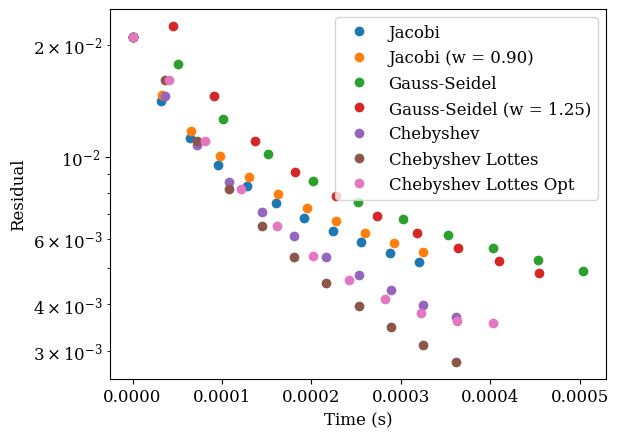

In [601]:
fig, ax = plt.subplots()
ax.semilogy(np.arange(nsmooth+1)*tj.average, rj, 'o', label=label_jacobi)
ax.semilogy(np.arange(nsmooth+1)*tjw.average, rjw, 'o', label=label_jacobi_w)
ax.semilogy(np.arange(nsmooth+1)*tg0.average, rg0, 'o', label=label_gs0)
ax.semilogy(np.arange(nsmooth+1)*tg.average, rg, 'o', label=label_gs)
ax.semilogy(np.arange(nsmooth+1)*tc.average, rc, 'o', label=label_c)
ax.semilogy(np.arange(nsmooth+1)*tc.average, rcl, 'o', label=label_cl)
ax.semilogy(np.arange(nsmooth+1)*tco.average, rclo, 'o', label=label_clo)
#plt.semilogy(tjs.best, rj[-1], 'v')
#plt.semilogy(tjws.best, rjw[-1], 'v')
#plt.semilogy(tg0s.best, rg0[-1], 'v')
#plt.semilogy(tgs.best, rg[-1], 'v')
#plt.semilogy(tcs.best, rc[-1], 'v')
#plt.semilogy(tcls.best, rcl[-1], 'v')
ax.set_ylabel('Residual')
ax.set_xlabel('Time (s)')
ax.legend()
plt.show()
plt.close(fig)
del fig,ax

# Define V-cycle iteration for all smoothers

In [602]:
param = {}
param["Npre"] = 2
param["Npost"] = 1
param["ncoarse"] = np.log2(n)
print(f"{param=}")

param={'Npre': 2, 'Npost': 1, 'ncoarse': np.float64(5.0)}


In [706]:
niter = 5
print(f"{residual_error(x0,b)=}")
rp_v = np.zeros(niter+1)
rj_v = np.zeros_like(rp_v)
rjw_v = np.zeros_like(rp_v)
rbj2_v = np.zeros_like(rp_v)
rbj4_v = np.zeros_like(rp_v)
rbj2w_v = np.zeros_like(rp_v)
rbj4w_v = np.zeros_like(rp_v)
rg0_v = np.zeros_like(rp_v)
rg_v = np.zeros_like(rp_v)
rc_v = np.zeros_like(rp_v)
rcl_v = np.zeros_like(rp_v)
rclo_v = np.zeros_like(rp_v)
rp_v[0] = rj_v[0] = rbj2_v[0] = rbj4_v[0] = rbj2w_v[0] = rbj4w_v[0] = rjw_v[0] = rg0_v[0] = rg_v[0] = rc_v[0] = rcl_v[0] = rclo_v[0] = re0
xp = x0.copy() 
xj = x0.copy() 
xbj2 = x0.copy() 
xbj4 = x0.copy() 
xbj2w = x0.copy() 
xbj4w = x0.copy() 
xjw = x0.copy() 
xg0 = x0.copy() 
xg = x0.copy() 
xc = x0.copy() 
xcl = x0.copy() 
xclo = x0.copy() 
r = rp_v.copy()
for i in range(niter):
    V_cycle(xp, b, param)
    V_cycle_jacobi(xj, b, param)
    V_cycle_jacobi_w(xjw, b, param, w)
    V_cycle_block_jacobi(xbj2, b, param, 2)
    V_cycle_block_jacobi(xbj4, b, param, 4)
    V_cycle_block_jacobi_w(xbj2w, b, param, 2, 1.1)
    V_cycle_block_jacobi_w(xbj4w, b, param, 4, 1.1)
    V_cycle_gs(xg0, b, param, f_relax0)
    V_cycle_gs(xg, b, param, f_relax)
    V_cycle_chebyshev1(xc, b, param, lambda_min, lambda_max)
    V_cycle_chebyshev4(xcl, b, param, lambda_max)
    V_cycle_chebyshev4_opt(xclo, b, param, lambda_max)
    rp_v[i+1] = residual_error(xp, b)
    rj_v[i+1] = residual_error(xj, b)
    rjw_v[i+1] = residual_error(xjw, b)
    rbj2_v[i+1] = residual_error(xbj2, b)
    rbj4_v[i+1] = residual_error(xbj4, b)
    rbj2w_v[i+1] = residual_error(xbj2w, b)
    rbj4w_v[i+1] = residual_error(xbj4w, b)
    rg0_v[i+1] = residual_error(xg0, b)
    rg_v[i+1] = residual_error(xg, b)
    rc_v[i+1] = residual_error(xc, b)
    rcl_v[i+1] = residual_error(xcl, b)    
    rclo_v[i+1] = residual_error(xclo, b)

residual_error(x0,b)=0.020999358966946602


## Plot residual for each V cycle iteration

In [707]:
rg_v_ref = rg_v.copy() # Use this as reference for best-case convergence, GS with w=1.25 with Npre=2, Npost=1

In [708]:
rp_v, rg_v, rbj4_v

(array([2.09993590e-02, 1.35488447e-03, 2.39047949e-05, 8.91478408e-07,
        4.80269229e-08, 2.93104545e-08]),
 array([2.09993590e-02, 1.35458622e-03, 2.39879337e-05, 8.98335429e-07,
        4.81463651e-08, 2.97060563e-08]),
 array([2.09993590e-02, 3.79833113e-03, 6.87443768e-04, 1.23776161e-04,
        2.22283779e-05, 3.98567727e-06]))

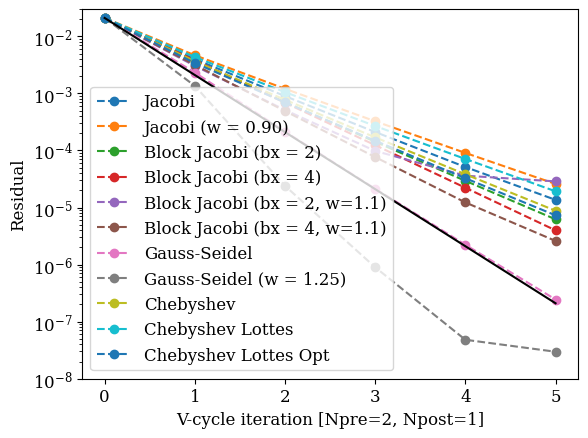

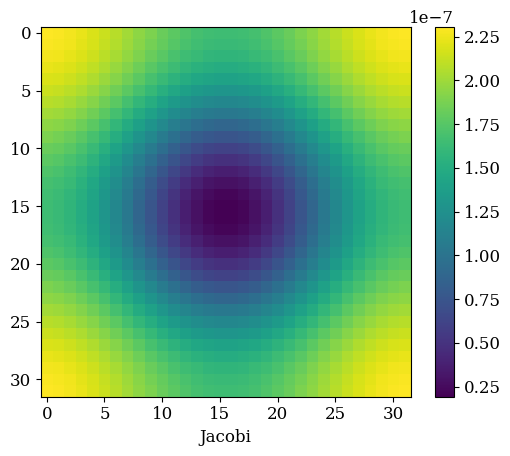

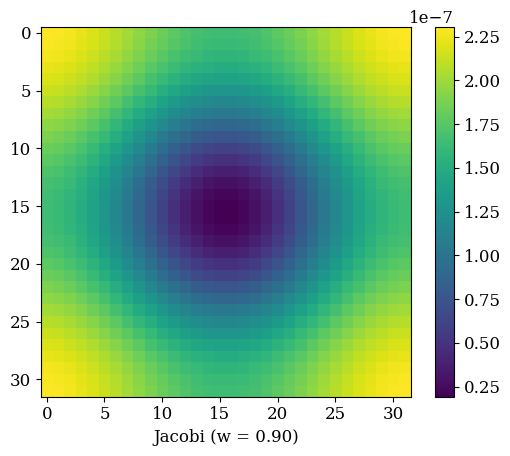

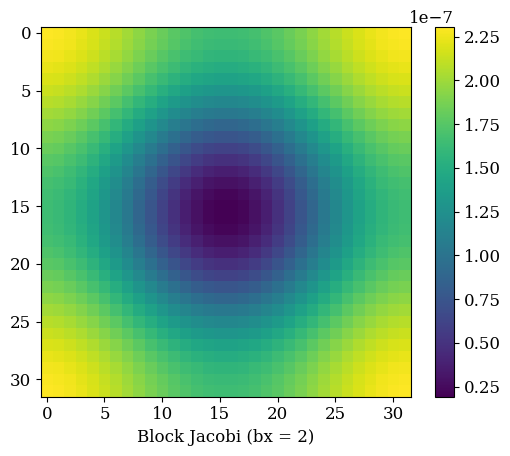

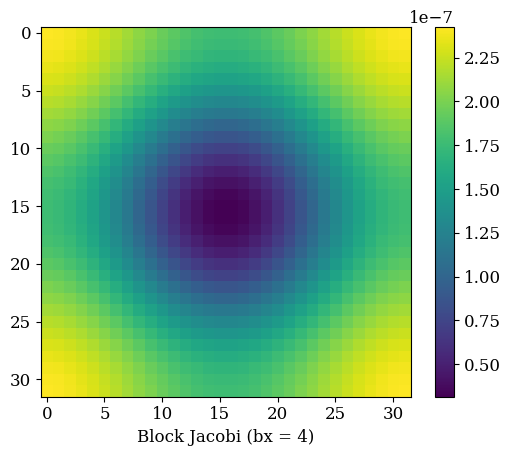

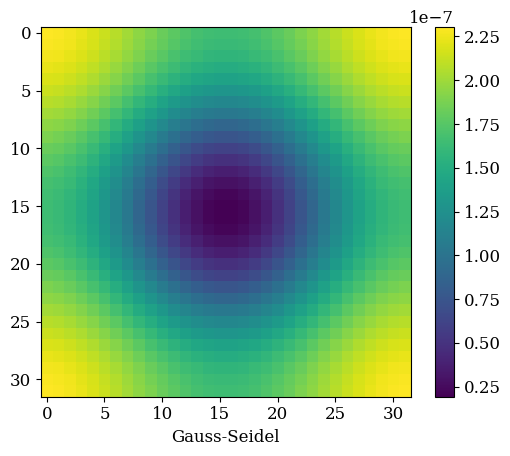

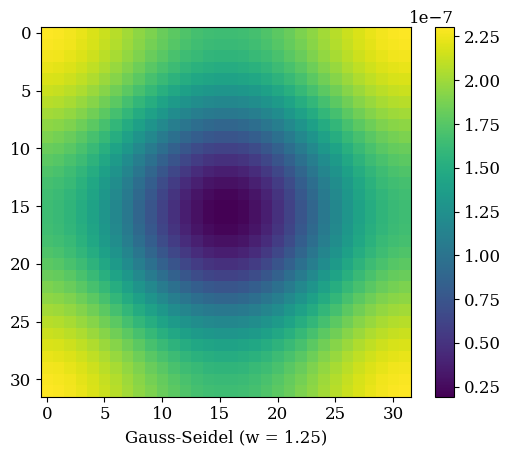

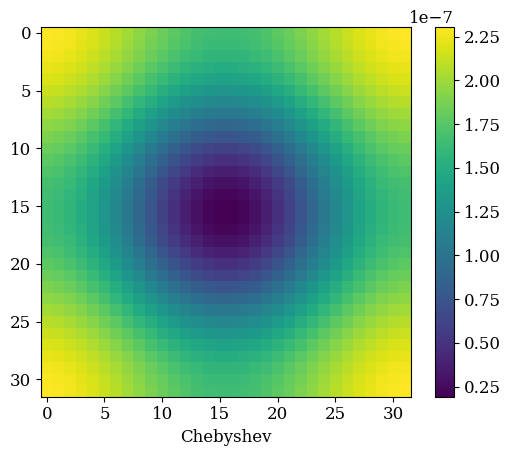

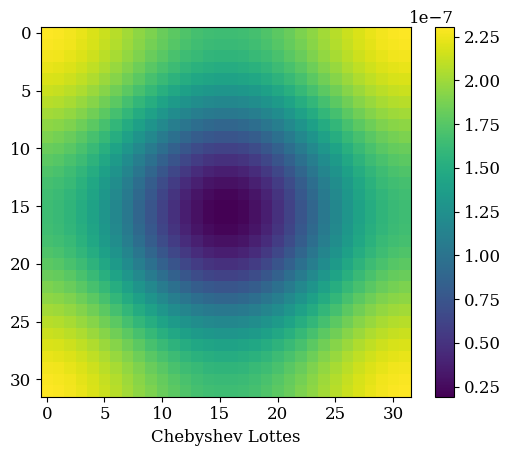

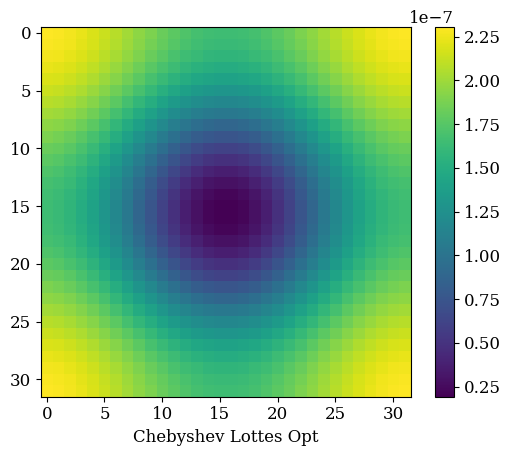

In [710]:
fig, ax = plt.subplots()
ax.semilogy(rj_v, "o", linestyle="--", label=label_jacobi)
ax.semilogy(rjw_v, "o", linestyle="--", label=label_jacobi_w)
ax.semilogy(rbj2_v, "o", linestyle="--", label=label_block_jacobi2)
ax.semilogy(rbj4_v, "o", linestyle="--", label=label_block_jacobi4)
ax.semilogy(rbj2w_v, "o", linestyle="--", label=label_block_jacobi2w)
ax.semilogy(rbj4w_v, "o", linestyle="--", label=label_block_jacobi4w)
ax.semilogy(rg0_v, "o", linestyle="--", label=label_gs0)
ax.semilogy(rg_v, "o", linestyle="--", label=label_gs)
ax.semilogy(rc_v, "o", linestyle="--", label=label_c)
ax.semilogy(rcl_v, "o", linestyle="--", label=label_cl)
ax.semilogy(rclo_v, "o", linestyle="--", label=label_clo)
#ax.semilogy(rp_v, '--', label="PySCo")
ax.semilogy(re0*0.1**np.arange(niter+1), "k")
ax.set_ylabel("Residual")
Npre = param["Npre"]
Npost = param["Npost"]
ax.set_xlabel(f"V-cycle iteration [{Npre=}, {Npost=}]")
ax.set_ylim(0.1**(niter+3), 3e-2)
ax.legend()
path="/local/home/mb280636/data/Dyablo/smoothers/pysco_tests"
#plt.savefig(f"{path}/residual_convergence_Vcycle_Npre{Npre}_Npost{Npost}.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close(fig)
del fig,ax

#plt.figure(0)
#plt.imshow(xp[0])
#plt.colorbar()
#plt.xlabel("PySCo")
fig, ax = plt.subplots()
im=ax.imshow(xj[0])
fig.colorbar(im,ax=ax)
ax.set_xlabel(label_jacobi)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xjw[0])
fig.colorbar(im,ax=ax)
ax.set_xlabel(label_jacobi_w)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xbj2[0])
fig.colorbar(im,ax=ax)
ax.set_xlabel(label_block_jacobi2)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xbj4[0])
fig.colorbar(im,ax=ax)
ax.set_xlabel(label_block_jacobi4)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xg0[0])
fig.colorbar(im,ax=ax)
ax.set_xlabel(label_gs0)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xg[0])
fig.colorbar(im,ax=ax)
ax.set_xlabel(label_gs)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xc[0])
fig.colorbar(im,ax=ax)
ax.set_xlabel(label_c)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xcl[0])
fig.colorbar(im,ax=ax)
ax.set_xlabel(label_cl)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xclo[0])
fig.colorbar(im,ax=ax)
ax.set_xlabel(label_clo)
plt.show()
plt.close(fig)
del fig,ax

# Fine-tuning parameters of smoothers

In [713]:
niter = 5 # Max number of V-cycles
nsmooth = 10 # Max number of smoothing interations for solver convergence
nsmooth_max = 5 # Maximum of Npre+Npost smoothing iterations for V cycles
blocksizes = [2,4]

In [712]:
npoints = 41
w_array = np.linspace(0.5, 1.5, npoints).astype(np.float32)
lambda_max_array = np.linspace(1., 3., npoints).astype(np.float32)
f_array = np.linspace(0., 0.4, npoints).astype(np.float32) # Used as lambda_min = f lambda_max
x = np.zeros_like(xp)
output_smooth = np.zeros((npoints, nsmooth+1)).astype(np.float32)
output = np.zeros((npoints, niter+1)).astype(np.float32)

if (len(w_array) != len(lambda_max_array)) or (len(w_array) != len(f_array)):
    raise ValueError(f"Check lengths {w_array.shape=} {lambda_max_array.shape=} {f_array.shape=}")
colors = pl.cm.coolwarm(np.linspace(0, 1, npoints))

## Jacobi

In [115]:
output_smooth.fill(0)
output_smooth[:,0] = re0
meta = {"w": w_array.tolist()}
header = json.dumps(meta)
for i, w in enumerate(w_array):
    x = x0.copy()
    for j in range(nsmooth):
        jacobi_w(tmp, x, b, w)
        tmp, x = x, tmp
        output_smooth[i,j+1] = residual_error(x,b)
    np.savetxt(f"{path}/jacobi_weight/residual_source_{source}_solver.dat", output_smooth.T, header=header,fmt="%.4e")

In [116]:
output.fill(0)
output[:,0] = re0
meta = {"w": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            resmin = re0
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            header = json.dumps(meta)
            for i, w in enumerate(w_array):
                x = x0.copy()
                for j in range(niter):
                    V_cycle_jacobi_w(x, b, param, w)
                    output[i,j+1] = residual_error(x,b)
                np.savetxt(f"{path}/jacobi_weight/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}.dat", output.T, header=header,fmt="%.4e")

## Block Jacobi

In [ ]:
for blocksize in blocksizes:
    output_smooth.fill(0)
    output_smooth[:,0] = re0
    meta = {"w": w_array.tolist()}
    header = json.dumps(meta)
    meta["blocksize"] = blocksize
    Ainv = compute_Ainv(blocksize)
    for i, w in enumerate(w_array):
        x = x0.copy()
        for j in range(nsmooth):
            block_jacobi_w(tmp, x, b, Ainv, w)
            tmp, x = x, tmp
            output_smooth[i,j+1] = residual_error(x,b)
        np.savetxt(f"{path}/block_jacobi/residual_source_{source}_solver_block_{blocksize}.dat", output_smooth.T, header=header,fmt="%.4e")

In [717]:
for blocksize in blocksizes:
    output.fill(0)
    output[:,0] = re0
    meta = {"w": w_array.tolist()}
    for Npre in range(nsmooth_max+1):
        for Npost in range(nsmooth_max+1):
            if Npre+Npost <= nsmooth_max:
                resmin = re0
                meta["Npre"] = Npre
                meta["Npost"] = Npost
                param["Npre"] = Npre
                param["Npost"] = Npost
                meta["blocksize"] = blocksize
                header = json.dumps(meta)
                for i, w in enumerate(w_array):
                    x = x0.copy()
                    for j in range(niter):
                        V_cycle_block_jacobi_w(x, b, param, blocksize, w)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/block_jacobi/residual_source_{source}_block_{blocksize}_Vcycle_Npre{Npre}_Npost{Npost}.dat", output.T, header=header,fmt="%.4e")

## Gauss-Seidel

In [117]:
output_smooth.fill(0)
output_smooth[:,0] = re0
meta = {"w": w_array.tolist()}
header = json.dumps(meta)
for i, w in enumerate(w_array):
    x = x0.copy() 
    for j in range(nsmooth):
        gauss_seidel(x, b, w)
        output_smooth[i,j+1] = residual_error(x,b)
    np.savetxt(f"{path}/gauss_seidel/residual_source_{source}_solver.dat", output_smooth.T, header=header,fmt="%.4e")

In [118]:
output.fill(0)
output[:,0] = re0
meta = {"w": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            header = json.dumps(meta)
            for i, w in enumerate(w_array):
                x = x0.copy()
                for j in range(niter):
                    V_cycle_gs(x, b, param, w)
                    output[i,j+1] = residual_error(x,b)
                np.savetxt(f"{path}/gauss_seidel/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}.dat", output.T, header=header,fmt="%.4e")

## Chebyshev

In [119]:
h = np.float32(1./x0.shape[0])
h2 = np.float32(h*h)
Dm1 = np.float32(-h*h/6.)

## Chebyshev 1st-kind

In [120]:
output_smooth.fill(0)
output_smooth[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
for f in f_array:
    meta["f"] = float(f)
    header = json.dumps(meta)
    for i, lambda_max in enumerate(lambda_max_array):
        lambda_min = f * lambda_max
        theta = np.float32(0.5) * (lambda_max + lambda_min)
        delta = np.float32(0.5) * (lambda_max - lambda_min)
        x = x0.copy() 
        rr = r0.copy()
        alpha, beta = chebyshev_coeffs(nsmooth, theta, delta)
        z = alpha[0]*Dm1*rr
        for j in range(nsmooth):
            chebyshev_form1(x, tmp, z, rr, alpha[j+1], beta[j+1])
            z, tmp = tmp, z
            output_smooth[i,j+1] = residual_error(x,b)
        np.savetxt(f"{path}/chebyshev1/residual_source_{source}_solver_f_{f:.3f}.dat", output_smooth.T, header=header,fmt="%.4e")

In [121]:
output_smooth.fill(0)
output_smooth[:,0] = re0
meta = {"f": f_array.tolist()}
header = json.dumps(meta)
for lambda_max in lambda_max_array:
    for i, f in enumerate(f_array):
        lambda_min = f * lambda_max
        theta = np.float32(0.5) * (lambda_max + lambda_min)
        delta = np.float32(0.5) * (lambda_max - lambda_min)
        x = x0.copy() 
        rr = r0.copy()
        alpha, beta = chebyshev_coeffs(nsmooth, theta, delta)
        z = alpha[0]*Dm1*rr
        for j in range(nsmooth):
            chebyshev_form1(x, tmp, z, rr, alpha[j+1], beta[j+1])
            z, tmp = tmp, z
            output_smooth[i,j+1] = residual_error(x,b)
        np.savetxt(f"{path}/chebyshev1/residual_source_{source}_solver_lambda_max_{lambda_max:.3f}.dat", output_smooth.T, header=header,fmt="%.4e")

In [122]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for f in f_array:
                meta["f"] = float(f)
                header = json.dumps(meta)
                for i, lambda_max in enumerate(lambda_max_array):
                    lambda_min = f * lambda_max
                    theta = np.float32(0.5) * (lambda_max + lambda_min)
                    delta = np.float32(0.5) * (lambda_max - lambda_min)
                    x = x0.copy() 
                    for j in range(niter):
                        V_cycle_chebyshev1(x, b, param, lambda_min, lambda_max)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/chebyshev1/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_f_{f:.3f}.dat", output.T, header=header,fmt="%.4e")

In [123]:
output.fill(0)
output[:,0] = re0
meta = {"f": f_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for lambda_max in lambda_max_array:
                meta["lambda_max"] = float(lambda_max)
                header = json.dumps(meta)
                for i, f in enumerate(f_array):
                    lambda_min = f * lambda_max
                    theta = np.float32(0.5) * (lambda_max + lambda_min)
                    delta = np.float32(0.5) * (lambda_max - lambda_min)
                    x = x0.copy() 
                    for j in range(niter):
                        V_cycle_chebyshev1(x, b, param, lambda_min, lambda_max)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/chebyshev1/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_lambda_max_{lambda_max:.3f}.dat", output.T, header=header,fmt="%.4e")

## Lottes Chebyshev 4th kind

In [124]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
header = json.dumps(meta)
for i, lambda_max in enumerate(lambda_max_array):
    x = x0.copy() 
    rr = r0.copy()
    nu = np.float32(4/lambda_max)
    alpha, beta = chebyshev_coeffs_lottes(nsmooth, nu)
    z = alpha[0]*Dm1*rr
    for j in range(nsmooth):
        chebyshev_form1(x, tmp, z, rr, alpha[j+1], beta[j+1])
        z, tmp = tmp, z
        output_smooth[i,j+1] = residual_error(x,b)
    np.savetxt(f"{path}/chebyshev4/residual_source_{source}_solver.dat", output_smooth.T, header=header,fmt="%.4e")

In [125]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            header = json.dumps(meta)
            for i, lambda_max in enumerate(lambda_max_array):
                x = x0.copy() 
                for j in range(niter):
                    V_cycle_chebyshev4(x, b, param, lambda_max)
                    output[i,j+1] = residual_error(x,b)
                np.savetxt(f"{path}/chebyshev4/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}.dat", output.T, header=header,fmt="%.4e")

## Lottes Chebyshev 4th kind Optimised

In [126]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
header = json.dumps(meta)
for i, lambda_max in enumerate(lambda_max_array):
    x = x0.copy() 
    rr = r0.copy()
    nu = np.float32(4/lambda_max)
    alpha, beta = chebyshev_coeffs_lottes(nsmooth, nu)
    gamma = gamma_tabular(nsmooth)
    z = alpha[0]*Dm1*rr
    for j in range(nsmooth):
        chebyshev_form1_opt(x, tmp, z, rr, alpha[j+1], beta[j+1], gamma[j])
        z, tmp = tmp, z
        output_smooth[i,j+1] = residual_error(x,b)
    np.savetxt(f"{path}/chebyshev4_opt/residual_source_{source}_solver.dat", output_smooth.T, header=header,fmt="%.4e")

In [127]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            header = json.dumps(meta)
            for i, lambda_max in enumerate(lambda_max_array):
                x = x0.copy() 
                for j in range(niter):
                    V_cycle_chebyshev4_opt(x, b, param, lambda_max)
                    output[i,j+1] = residual_error(x,b)
                np.savetxt(f"{path}/chebyshev4_opt/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}.dat", output.T, header=header,fmt="%.4e")

# Multigrid with mixed smoothers

## Jacobi - Jacobi (different weights)

In [128]:
output.fill(0)
output[:,0] = re0
meta = {"w2": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for w1 in w_array:
                meta["w1"] = float(w1)
                header = json.dumps(meta)
                for i, w2 in enumerate(w_array):
                    x = x0.copy()
                    for j in range(niter):
                        V_cycle_jacobi_w1w2(x, b, param, w1,w2)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/jacobi-jacobi/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_w1_{w1:.3f}.dat", output.T, header=header,fmt="%.4e")

In [129]:
output.fill(0)
output[:,0] = re0
meta = {"w1": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for w2 in w_array:
                meta["w2"] = float(w2)
                header = json.dumps(meta)
                for i, w1 in enumerate(w_array):
                    x = x0.copy()
                    for j in range(niter):
                        V_cycle_jacobi_w1w2(x, b, param, w1,w2)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/jacobi-jacobi/jacobi_residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_w2_{w2:.3f}.dat", output.T, header=header,fmt="%.4e")

## Gauss-Seidel - Gauss-Seidel (different weights)

In [130]:
output.fill(0)
output[:,0] = re0
meta = {"w2": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for w1 in w_array:
                meta["w1"] = float(w1)
                header = json.dumps(meta)
                for i, w2 in enumerate(w_array):
                    x = x0.copy()
                    for j in range(niter):
                        V_cycle_gs_w1w2(x, b, param, w1,w2)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/gs-gs/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_w1_{w1:.3f}.dat", output.T, header=header,fmt="%.4e")

In [131]:
output.fill(0)
output[:,0] = re0
meta = {"w1": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for w2 in w_array:
                meta["w2"] = float(w2)
                header = json.dumps(meta)
                for i, w1 in enumerate(w_array):
                    x = x0.copy()
                    for j in range(niter):
                        V_cycle_gs_w1w2(x, b, param, w1,w2)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/gs-gs/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_w2_{w2:.3f}.dat", output.T, header=header,fmt="%.4e")

## Jacobi - Gauss-Seidel

In [132]:
output.fill(0)
output[:,0] = re0
meta = {"w2": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for w1 in w_array:
                meta["w1"] = float(w1)
                header = json.dumps(meta)
                for i, w2 in enumerate(w_array):
                    x = x0.copy()
                    for j in range(niter):
                        V_cycle_jacobi_gs(x, b, param, w1,w2)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/jacobi-gs/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_w1_{w1:.3f}.dat", output.T, header=header,fmt="%.4e")

## (Gauss-Seidel - Jacobi)

## Chebyshev 1st - Gauss-Seidel

In [133]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
for Npre in prange(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for f in f_array:
                meta["f"] = float(f)
                for w in w_array:
                    meta["w"] = float(w)
                    header = json.dumps(meta)
                    for i, lambda_max in enumerate(lambda_max_array):
                        lambda_min = f*lambda_max
                        x = x0.copy() 
                        for j in range(niter):
                            V_cycle_chebyshev1_gs(x, b, param, lambda_min, lambda_max, w)
                            output[i,j+1] = residual_error(x,b)
                        np.savetxt(f"{path}/chebyshev1-gs/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_f_{f:.3f}_w_{w:.3f}.dat", output.T, header=header,fmt="%.4e")

## Chebyshev 4th - Gauss-Seidel

In [134]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for w in w_array:
                meta["w"] = float(w)
                header = json.dumps(meta)
                for i, lambda_max in enumerate(lambda_max_array):
                    x = x0.copy() 
                    for j in range(niter):
                        V_cycle_chebyshev4_gs(x, b, param, lambda_max, w)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/chebyshev4-gs/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_w_{w:.3f}.dat", output.T, header=header,fmt="%.4e")

In [135]:
output.fill(0)
output[:,0] = re0
meta = {"w": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for lambda_max in lambda_max_array:
                meta["lambda_max"] = float(lambda_max)
                header = json.dumps(meta)
                for i, w in enumerate(w_array):
                    x = x0.copy() 
                    for j in range(niter):
                        V_cycle_chebyshev4_gs(x, b, param, lambda_max, w)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/chebyshev4-gs/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_lambda_max_{lambda_max:.3f}.dat", output.T, header=header,fmt="%.4e")

## Chebyshev 4th (Opt) - Gauss-Seidel

In [136]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for w in w_array:
                meta["w"] = float(w)
                header = json.dumps(meta)
                for i, lambda_max in enumerate(lambda_max_array):
                    x = x0.copy() 
                    for j in range(niter):
                        V_cycle_chebyshev4_opt_gs(x, b, param, lambda_max, w)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/chebyshev4_opt-gs/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_w_{w:.3f}.dat", output.T, header=header,fmt="%.4e")

In [137]:
output.fill(0)
output[:,0] = re0
meta = {"w": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for lambda_max in lambda_max_array:
                meta["lambda_max"] = float(lambda_max)
                header = json.dumps(meta)
                for i, w in enumerate(w_array):
                    x = x0.copy() 
                    for j in range(niter):
                        V_cycle_chebyshev4_opt_gs(x, b, param, lambda_max, w)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/chebyshev4_opt-gs/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_lambda_max_{lambda_max:.3f}.dat", output.T, header=header,fmt="%.4e")

## Chebyshev 1st - Jacobi

In [138]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
for Npre in prange(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for f in f_array:
                meta["f"] = float(f)
                for w in w_array:
                    meta["w"] = float(w)
                    header = json.dumps(meta)
                    for i, lambda_max in enumerate(lambda_max_array):
                        lambda_min = f*lambda_max
                        x = x0.copy() 
                        for j in range(niter):
                            V_cycle_chebyshev1_jacobi(x, b, param, lambda_min, lambda_max, w)
                            output[i,j+1] = residual_error(x,b)
                        np.savetxt(f"{path}/chebyshev1-jacobi/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_f_{f:.3f}_w_{w:.3f}.dat", output.T, header=header,fmt="%.4e")

KeyboardInterrupt: 

## Chebyshev 4th - Jacobi

In [139]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for w in w_array:
                meta["w"] = float(w)
                header = json.dumps(meta)
                for i, lambda_max in enumerate(lambda_max_array):
                    x = x0.copy() 
                    for j in range(niter):
                        V_cycle_chebyshev4_jacobi(x, b, param, lambda_max, w)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/chebyshev4-jacobi/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_w_{w:.3f}.dat", output.T, header=header,fmt="%.4e")

In [140]:
output.fill(0)
output[:,0] = re0
meta = {"w": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for lambda_max in lambda_max_array:
                meta["lambda_max"] = float(lambda_max)
                header = json.dumps(meta)
                for i, w in enumerate(w_array):
                    x = x0.copy() 
                    for j in range(niter):
                        V_cycle_chebyshev4_jacobi(x, b, param, lambda_max, w)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/chebyshev4-jacobi/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_lambda_max_{lambda_max:.3f}.dat", output.T, header=header,fmt="%.4e")

## Chebyshev 4th Optimised - Jacobi

In [141]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for w in w_array:
                meta["w"] = float(w)
                header = json.dumps(meta)
                for i, lambda_max in enumerate(lambda_max_array):
                    x = x0.copy() 
                    for j in range(niter):
                        V_cycle_chebyshev4_opt_jacobi(x, b, param, lambda_max, w)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/chebyshev4_opt-jacobi/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_w_{w:.3f}.dat", output.T, header=header,fmt="%.4e")

In [167]:
output.fill(0)
output[:,0] = re0
meta = {"w": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for lambda_max in lambda_max_array:
                meta["lambda_max"] = float(lambda_max)
                header = json.dumps(meta)
                for i, w in enumerate(w_array):
                    x = x0.copy() 
                    for j in range(niter):
                        V_cycle_chebyshev4_opt_jacobi(x, b, param, lambda_max, w)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/chebyshev4_opt-jacobi/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_lambda_max_{lambda_max:.3f}.dat", output.T, header=header,fmt="%.4e")

# Infer best-fit parameters

In [11]:
from nautilus import Prior
from nautilus import Sampler
from iminuit import Minuit
import corner
import math
from getdist import MCSamples, plots

In [12]:
def plot_posterior(output_name, title, names, labels, plot_names, samplers ):
    samples = []
    best_points = []
    labels_bestfit = []
    for i, sampler in enumerate(samplers):
        points, log_w, log_l = sampler.posterior()
        best_idx = np.argmax(log_l)
        best_point = points[best_idx]
        best_points.append(best_point)
        best_log_l = log_l[best_idx]
        print(best_point[:len(plot_names)])
        
        # Plot posterior
        weights = np.exp(log_w - np.max(log_w))
        weights /= np.sum(weights)
        label_bestfit = [f"{point:.2f} " for point in best_point]
        labels_bestfit.append(label_bestfit)
        samples.append(MCSamples(samples=points, weights=weights, loglikes=log_l, names=names, labels=labels, label=f"{i+1} cycles {np.array(label_bestfit).astype(np.float32)}"))
    if len(plot_names) == 1:
        g = plots.get_single_plotter(width_inch=4)
        labels = [f"{i+1} cycles [{float(labels_bestfit[i][0]):.2f}]" for i in range(len(samplers))]
        g.add_legend(labels);
        plt.title(title)
        g.plot_1d(samples, plot_names[0], normalized=True)
    else:
        g = plots.get_subplot_plotter()
        g.triangle_plot(samples, plot_names, filled=True, shaded=False)
    g.export(output_name, dpi=300)

In [211]:
chain_path = "/local/home/mb280636/data/Dyablo/smoothers/pysco_tests/chains"
param = {}
param["Npre"] = 1
param["Npost"] = 2
param["ncoarse"] = np.log2(n)
niter = 5

In [212]:
residual_ref = residual_error(x0, b)*0.1**np.arange(10)
print(residual_ref)

[2.0999359e-02 2.0999359e-03 2.0999359e-04 2.0999359e-05 2.0999359e-06
 2.0999359e-07 2.0999359e-08 2.0999359e-09 2.0999359e-10 2.0999359e-11]


In [213]:
def make_nautilus_priors(names, priors):
    prior = Prior()
    for name, bounds in zip(names, priors):
        prior.add_parameter(name, dist=tuple(bounds))
    return prior


def run_minuit(n_cycles, guess, priors, compute_residual):
    def chi_sq(*theta):
        return compute_residual(theta, n_cycles)**2

    m = Minuit(chi_sq, *guess)
    m.limits = priors
    m.errordef = 1
    m.migrad()

    theta_best = np.array([m.values[i] for i in range(len(guess))])
    res0 = compute_residual(theta_best, n_cycles)

    return theta_best, res0

def run_nested_sampling(n_cycles, res0, prior, param_names, compute_residual, n_live=1000):

    def log_likelihood(param_dict):
        theta = [float(param_dict[name]) for name in param_names]
        res = compute_residual(theta, n_cycles)

        if not np.isfinite(res):
            return -np.inf

        return -0.5 * (res / res0)**2

    sampler = Sampler(prior, log_likelihood, n_live=n_live)
    sampler.run(verbose=True)

    return sampler

def run_fitting(niter, guess, priors, prior, residual):
    samplers = []
    for n_cycles in range(1, niter):
        # ---------- Minuit optimization ----------
        theta_best, res0 = run_minuit(n_cycles, guess, priors, compute_residual)
        print(f"[n_cycles={n_cycles}] bestfit = {theta_best}, res0 = {res0:.3e}")
        # ---------- Nested sampling ----------
        sampler = run_nested_sampling(n_cycles, res0, prior, param_names, compute_residual) 
        samplers.append(sampler)
    return samplers

def plot_bestfit(param, title, nparam, samplers):
    # Ref GS (2-1) w = 1.25
    def load_dat_with_json_header(filename):
        with open(filename, "r") as f:
            header_line = f.readline()[2:]  # remove # and whitespace
            meta = json.loads(header_line)
        data = np.loadtxt(filename, skiprows=1)
        return meta, data
        
    meta, data = load_dat_with_json_header(f"{chain_path}/../gauss_seidel/residual_source_hernquist_Vcycle_Npre2_Npost1.dat")
    w = np.array(meta["w"])
    idx = np.where(np.isclose(w, 1.25))[0][0]
    print(f"{idx=} {meta['w'][idx]=}")
    dat_ref = data[:,idx]
    
    output = f"{chain_path}/{title}_Npre{param['Npre']}_Npost{param['Npost']}.png"
    fig, ax = plt.subplots()
    for icycle, sampler in enumerate(samplers):
        points, log_w, log_l = sampler.posterior()
        best_idx = np.argmax(log_l)
        best_point = points[best_idx]
        label_bestfit = [f"{point:.2f} " for point in best_point]
        residual = np.zeros(niter+1)
        residual[0] = re0
        xlabel = fr"V-cycle iteration $[N_{{\rm pre}}={param['Npre']}, N_{{\rm post}} = {param['Npost']}]$"
        for i in range(1,niter+1): 
            residual[i] = compute_residual(best_point, i)
        plt.semilogy(residual, label=fr"{icycle+1} $\mathrm{{cycles}}$ {np.array(label_bestfit[:nparam]).astype(np.float32)}")
        resmin = np.min(residual[np.isfinite(residual)])
    ax.set_ylabel("Residual")
    ax.set_xlabel(xlabel)
    ax.set_ylim(0.9*resmin, 1.1*residual[0])
    ax.semilogy(range(niter+1), residual[0]*0.1**np.arange(niter+1), 'k--', label=r"$\mathrm{Decay}: 0.1$")
    ax.semilogy(dat_ref, "v", color="k", linestyle=":", label="GS 2-1")
    ax.legend(ncol=1, bbox_to_anchor=(1.0, 0.),loc="lower left",)
    ax.set_title(title)
    fig.savefig(output, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)
    del fig,ax

# Jacobi

[n_cycles=1] bestfit = [1.36510241 1.25      ], res0 = 2.772e-03
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 9      | 1        | 4        | 14600    | N/A    | 10019 | -1.81    
[n_cycles=2] bestfit = [1.1689735 1.25     ], res0 = 6.485e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 10     | 1        | 4        | 15700    | N/A    | 10097 | -2.55    
[n_cycles=3] bestfit = [1.07888531 1.25      ], res0 = 1.727e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 10     | 1        | 4        | 15900    | N/A    | 10024 | -3.01    
[n_cycles=4] bestfit = [1.03320015 1.25      ], res

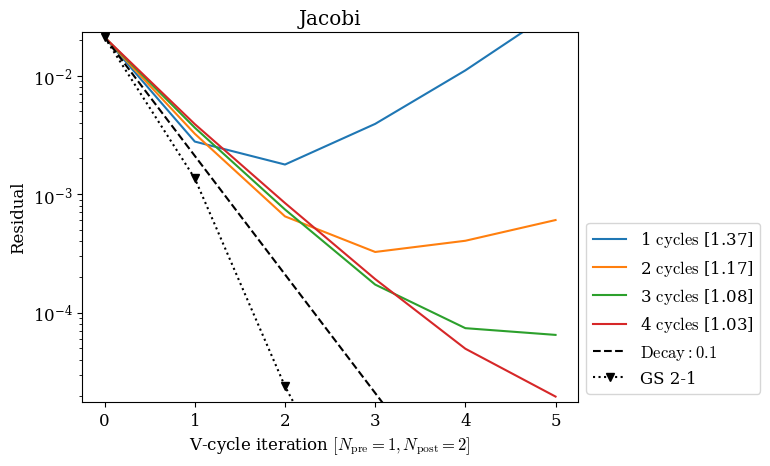

In [214]:
param_names = ["w1", "w2"]
priors = np.array([[0,2.5],
                   [0,2.5]])
guess = np.mean(priors, axis=1)
prior = make_nautilus_priors(param_names, priors)

# -------------------------------------------------
# Core residual evaluator
# -------------------------------------------------
def compute_residual(theta, n_cycles):
    x = x0.copy()
    w1 = float(theta[0])
    for _ in range(n_cycles):
        V_cycle_jacobi_w1w2(x, b, param, w1, w1)
    return residual_error(x, b)
# -------------------------------------------------
# Main loop over iteration count
# -------------------------------------------------
sampler_j = run_fitting(niter, guess, priors, prior, residual)    

# -------------------------------------------------
# Compute residual for bestfit parameters
# -------------------------------------------------
title = "Jacobi"
nparam = 1
plot_bestfit(param, title, nparam, sampler_j)

[1.3653273]
Removed no burn in
[1.17004546]
Removed no burn in
[1.08278138]
Removed no burn in
[1.03472333]
Removed no burn in


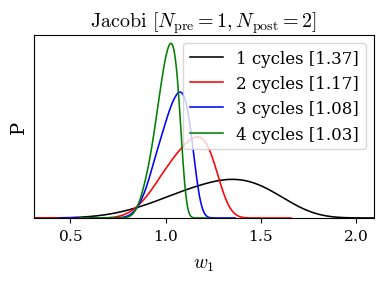

In [215]:
names = ["w1", "w2"]
labels = [r"w_1", r"w_2"]
plot_names = ["w1"]
output_name = f"{chain_path}/jacobi_source_{source}_Npre{param['Npre']}_Npost{param['Npost']}.png"
title = fr"$\mathrm{{Jacobi}}$ $[N_{{\rm pre}}={param['Npre']}, N_{{\rm post}} = {param['Npost']}]$"
plot_posterior(output_name, title, names, labels, plot_names, sampler_j )

# Jacobi - Jacobi

[n_cycles=1] bestfit = [1.45071206 1.32885581], res0 = 2.718e-03
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 9      | 1        | 4        | 14300    | N/A    | 10091 | -1.37    
[n_cycles=2] bestfit = [1.15051765 1.1816198 ], res0 = 6.522e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 9      | 1        | 4        | 14900    | N/A    | 10051 | -1.89    
[n_cycles=3] bestfit = [1.00793433 1.14646019], res0 = 1.796e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 10     | 1        | 4        | 15700    | N/A    | 10071 | -2.15    
[n_cycles=4] bestfit = [0.74830373 1.0411596 ], r

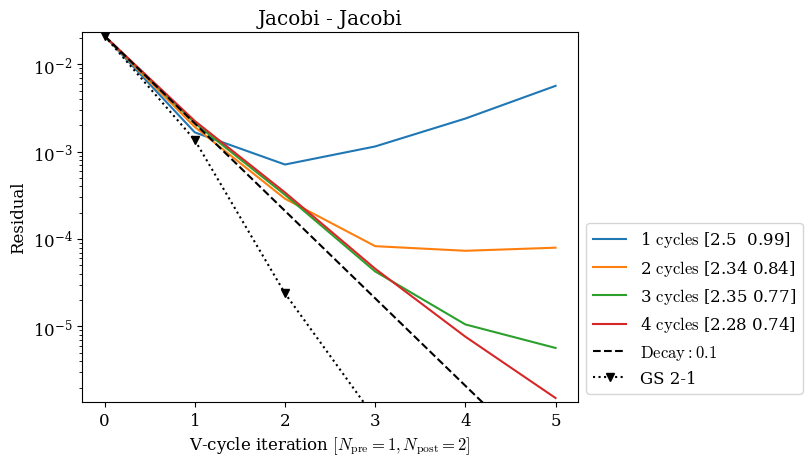

In [216]:
param_names = ["w1", "w2"]
priors = np.array([[0,2.5],
                   [0,2.5]])
guess = np.mean(priors, axis=1)
prior = make_nautilus_priors(param_names, priors)

# -------------------------------------------------
# Core residual evaluator
# -------------------------------------------------
def compute_residual(theta, n_cycles):
    x = x0.copy()
    w1 = float(theta[0])
    w2 = float(theta[1])
    for _ in range(n_cycles):
        V_cycle_jacobi_w1w2(x, b, param, w1, w2)
    return residual_error(x, b)
# -------------------------------------------------
# Main loop over iteration count
# -------------------------------------------------
sampler_jj = run_fitting(niter, guess, priors, prior, residual)

# -------------------------------------------------
# Compute residual for bestfit parameters
# -------------------------------------------------
title = "Jacobi - Jacobi"
nparam = 2
plot_bestfit(param, title, nparam, sampler_jj)

[2.49916674 0.98687374]
Removed no burn in
[2.33546518 0.84405101]
Removed no burn in
[2.35351052 0.77025041]
Removed no burn in
[2.2762875  0.73816669]
Removed no burn in


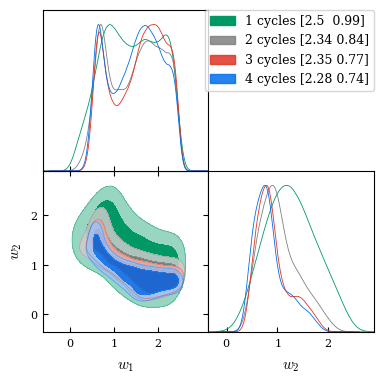

In [217]:
names = ["w1", "w2"]
labels = [r"w_1", r"w_2"]
output_name = f"{chain_path}/jacobi-jacobi_source_{source}_Npre{param['Npre']}_Npost{param['Npost']}.png"
title = fr"$\mathrm{{Jacobi-Jacobi}}$ $[N_{{\rm pre}}={param['Npre']}, N_{{\rm post}} = {param['Npost']}]$"
plot_posterior(output_name, title, names, labels, names, sampler_jj )

# Gauss-Seidel

[n_cycles=1] bestfit = [1.23413172 1.25      ], res0 = 7.964e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 11     | 1        | 4        | 16100    | N/A    | 10053 | -3.24    
[n_cycles=2] bestfit = [1.25152 1.25   ], res0 = 2.484e-05
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 12     | 1        | 4        | 17400    | N/A    | 10022 | -3.82    
[n_cycles=3] bestfit = [1.27323887 1.25      ], res0 = 9.959e-07
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 12     | 1        | 4        | 18800    | N/A    | 10003 | -4.19    
[n_cycles=4] bestfit = [1.28004589 1.25      ], res0 = 

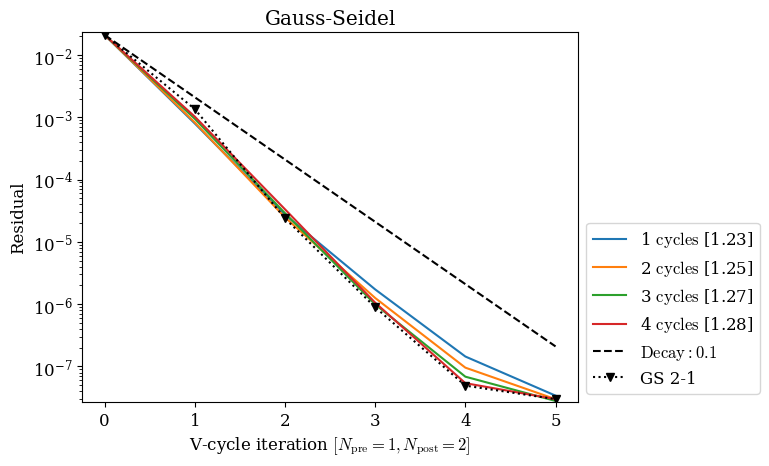

In [218]:
param_names = ["w1", "w2"]
priors = np.array([[0,2.5],
                   [0,2.5]])
guess = np.mean(priors, axis=1)
prior = make_nautilus_priors(param_names, priors)

# -------------------------------------------------
# Core residual evaluator
# -------------------------------------------------
def compute_residual(theta, n_cycles):
    x = x0.copy()
    w1 = float(theta[0])
    for _ in range(n_cycles):
        V_cycle_gs_w1w2(x, b, param, w1, w1)
    return residual_error(x, b)
# -------------------------------------------------
# Main loop over iteration count
# -------------------------------------------------
sampler_g = run_fitting(niter, guess, priors, prior, residual)

# -------------------------------------------------
# Compute residual for bestfit parameters
# -------------------------------------------------
title = "Gauss-Seidel"
nparam = 1
plot_bestfit(param, title, nparam, sampler_g)

[1.23416981]
Removed no burn in
[1.25182833]
Removed no burn in
[1.27322158]
Removed no burn in
[1.28268584]
Removed no burn in


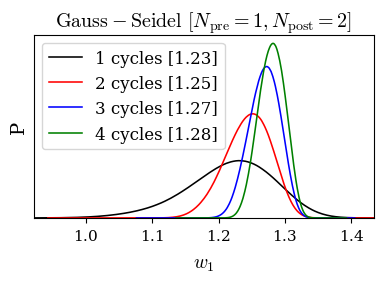

In [219]:
output_name = f"{chain_path}/gs_source_{source}_Npre{param['Npre']}_Npost{param['Npost']}.png"
title = fr"$\mathrm{{Gauss-Seidel}}$ $[N_{{\rm pre}}={param['Npre']}, N_{{\rm post}} = {param['Npost']}]$"
plot_posterior(output_name, title, names, labels, plot_names, sampler_g )

# Gauss-Seidel - Gauss-Seidel

[n_cycles=1] bestfit = [1.25575582 1.19890892], res0 = 7.341e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 12     | 1        | 4        | 16500    | N/A    | 10004 | -4.01    
[n_cycles=2] bestfit = [1.27963142 1.24372423], res0 = 2.396e-05
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 13     | 1        | 4        | 18400    | N/A    | 10095 | -4.88    
[n_cycles=3] bestfit = [1.30416656 1.24505027], res0 = 9.254e-07
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 14     | 1        | 4        | 19100    | N/A    | 10040 | -5.50    
[n_cycles=4] bestfit = [1.31031052 1.25968307], r

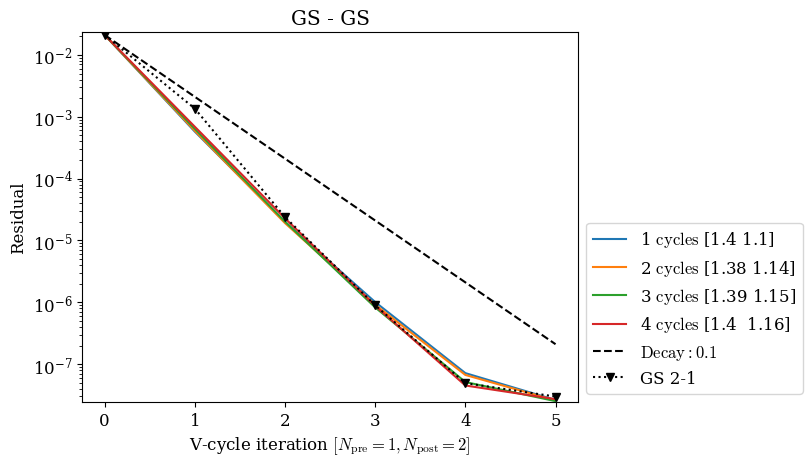

In [220]:
param_names = ["w1", "w2"]
priors = np.array([[0,2.5],
                   [0,2.5]])
guess = np.mean(priors, axis=1)
prior = make_nautilus_priors(param_names, priors)

# -------------------------------------------------
# Core residual evaluator
# -------------------------------------------------
def compute_residual(theta, n_cycles):
    x = x0.copy()
    w1 = float(theta[0])
    w2 = float(theta[1])
    for _ in range(n_cycles):
        V_cycle_gs_w1w2(x, b, param, w1, w2)
    return residual_error(x, b)
# -------------------------------------------------
# Main loop over iteration count
# -------------------------------------------------
sampler_gg = run_fitting(niter, guess, priors, prior, residual)

# -------------------------------------------------
# Compute residual for bestfit parameters
# -------------------------------------------------
title = "GS - GS"
nparam = 2
plot_bestfit(param, title, nparam, sampler_gg)

[1.40333092 1.09689975]
Removed no burn in
[1.38261604 1.13527396]
Removed no burn in
[1.38916611 1.15244373]
Removed no burn in
[1.40122961 1.1605284 ]
Removed no burn in


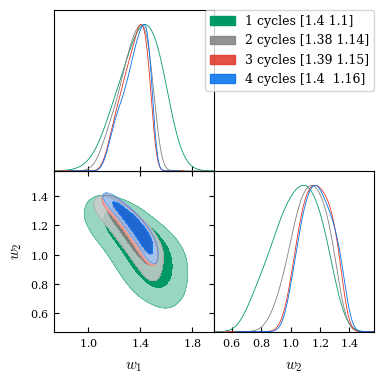

In [221]:
names = ["w1", "w2"]
labels = [r"w_1", r"w_2"]
output_name = f"{chain_path}/gs-gs_source_{source}_Npre{param['Npre']}_Npost{param['Npost']}.png"
title = fr"$\mathrm{{GS-GS}}$ $[N_{{\rm pre}}={param['Npre']}, N_{{\rm post}} = {param['Npost']}]$"
plot_posterior(output_name, title, names, labels, names, sampler_gg )

# Jacobi - Gauss-Seidel

[n_cycles=1] bestfit = [2.49993683 1.11973572], res0 = 1.465e-03
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 11     | 1        | 4        | 15000    | N/A    | 10004 | -2.95    
[n_cycles=2] bestfit = [0.67159772 1.37209504], res0 = 4.029e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 10     | 1        | 4        | 15100    | N/A    | 10046 | -2.26    
[n_cycles=3] bestfit = [0.78863734 1.35446413], res0 = 7.348e-05
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 10     | 1        | 4        | 15700    | N/A    | 10058 | -2.58    
[n_cycles=4] bestfit = [1.18836183 1.09937169], r

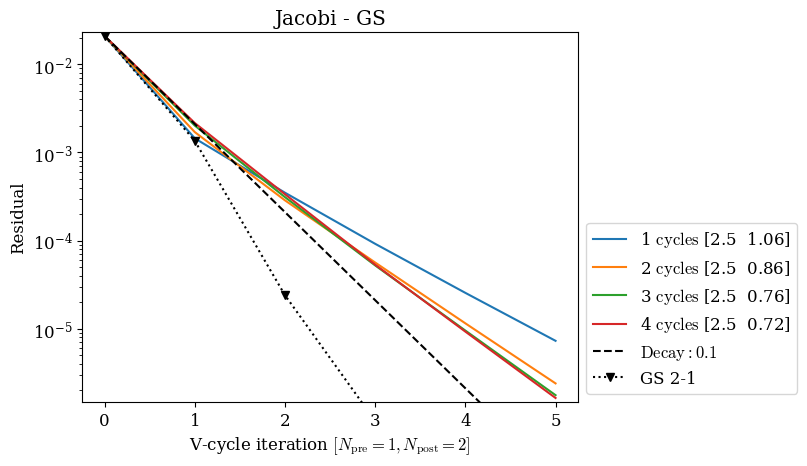

In [222]:
param_names = ["w1", "w2"]
priors = np.array([[0,2.5],
                   [0,2.5]])
guess = np.mean(priors, axis=1)
prior = make_nautilus_priors(param_names, priors)

# -------------------------------------------------
# Core residual evaluator
# -------------------------------------------------
def compute_residual(theta, n_cycles):
    x = x0.copy()
    w1 = float(theta[0])
    w2 = float(theta[1])
    for _ in range(n_cycles):
        V_cycle_jacobi_gs(x, b, param, w1, w2)
    return residual_error(x, b)
# -------------------------------------------------
# Main loop over iteration count
# -------------------------------------------------
sampler_jg = run_fitting(niter, guess, priors, prior, residual)

# -------------------------------------------------
# Compute residual for bestfit parameters
# -------------------------------------------------
title = "Jacobi - GS"
nparam = 2
plot_bestfit(param, title, nparam, sampler_jg)

[2.49998819 1.05651375]
Removed no burn in
[2.49987747 0.85576791]
Removed no burn in
[2.49976932 0.75618483]
Removed no burn in
[2.49950893 0.72383403]
Removed no burn in


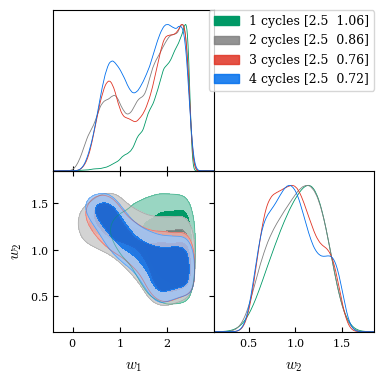

In [223]:
names = ["w1", "w2"]
labels = [r"w_1", r"w_2"]
output_name = f"{chain_path}/jacobi-gs_source_{source}_Npre{param['Npre']}_Npost{param['Npost']}.png"
title = fr"$\mathrm{{Jacobi-GS}}$ $[N_{{\rm pre}}={param['Npre']}, N_{{\rm post}} = {param['Npost']}]$"
plot_posterior(output_name, title, names, labels, names, sampler_jg )

# Gauss-Seidel - Jacobi

[n_cycles=1] bestfit = [0.66128913 0.9405764 ], res0 = 5.661e-03
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 9      | 1        | 4        | 14800    | N/A    | 10073 | -1.62    
[n_cycles=2] bestfit = [0.88735775 0.84324093], res0 = 1.279e-03
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 10     | 1        | 4        | 15100    | N/A    | 10059 | -2.05    
[n_cycles=3] bestfit = [0.97666007 0.80741773], res0 = 2.645e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 10     | 1        | 4        | 15700    | N/A    | 10007 | -2.28    
[n_cycles=4] bestfit = [1.20171763 1.14778455], r

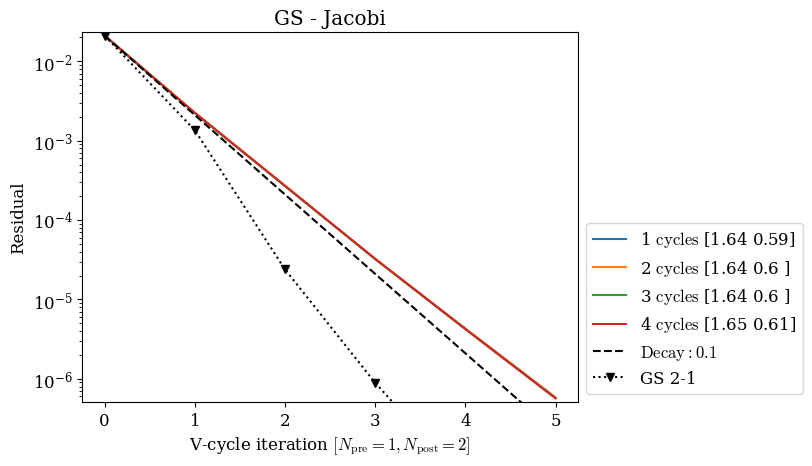

In [224]:
param_names = ["w1", "w2"]
priors = np.array([[0,2.5],
                   [0,2.5]])
guess = np.mean(priors, axis=1)
prior = make_nautilus_priors(param_names, priors)

# -------------------------------------------------
# Core residual evaluator
# -------------------------------------------------
def compute_residual(theta, n_cycles):
    x = x0.copy()
    w1 = float(theta[0])
    w2 = float(theta[1])
    for _ in range(n_cycles):
        V_cycle_gs_jacobi(x, b, param, w1, w2)
    return residual_error(x, b)
# -------------------------------------------------
# Main loop over iteration count
# -------------------------------------------------
sampler_gj = run_fitting(niter, guess, priors, prior, residual)

# -------------------------------------------------
# Compute residual for bestfit parameters
# -------------------------------------------------
title = "GS - Jacobi"
nparam = 2
plot_bestfit(param, title, nparam, sampler_gj)

[1.6407393  0.59457427]
Removed no burn in
[1.63677989 0.59997171]
Removed no burn in
[1.64343946 0.60482802]
Removed no burn in
[1.65205489 0.60896632]
Removed no burn in


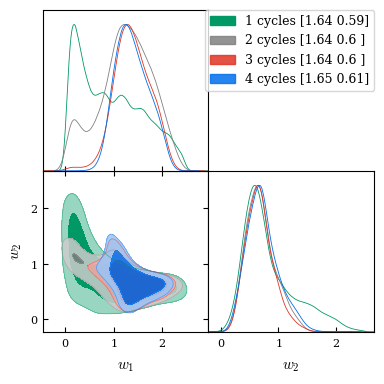

In [225]:
names = ["w1", "w2"]
labels = [r"w_1", r"w_2"]
output_name = f"{chain_path}/jacobi-gs_source_{source}_Npre{param['Npre']}_Npost{param['Npost']}.png"
title = fr"$\mathrm{{Jacobi-GS}}$ $[N_{{\rm pre}}={param['Npre']}, N_{{\rm post}} = {param['Npost']}]$"
plot_posterior(output_name, title, names, labels, names, sampler_gj )

# Chebyshev 1st

[n_cycles=1] bestfit = [1.22457441 0.227796  ], res0 = 2.533e-03
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 9      | 1        | 4        | 14000    | N/A    | 10055 | -1.73    
[n_cycles=2] bestfit = [1.30220968 0.3155595 ], res0 = 5.868e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 9      | 1        | 4        | 14900    | N/A    | 10022 | -2.09    
[n_cycles=3] bestfit = [1.34727089 0.33860161], res0 = 1.703e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 10     | 1        | 4        | 15000    | N/A    | 10020 | -2.13    
[n_cycles=4] bestfit = [1.34051302 0.33234133], r

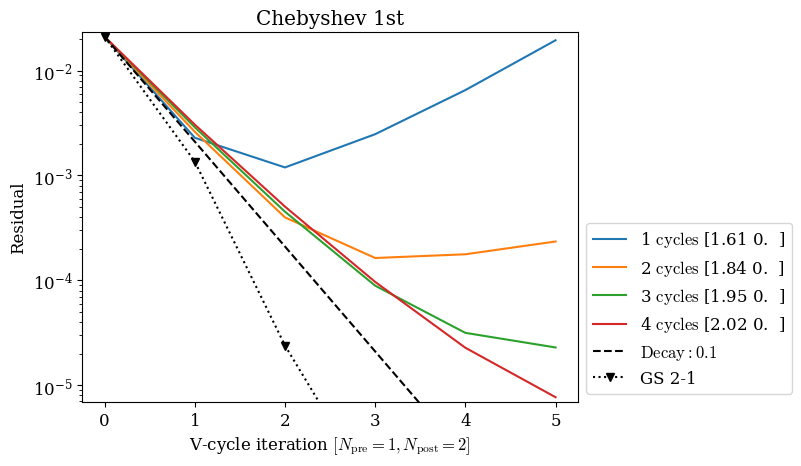

In [226]:
param_names = ["lambda_max", "f"]
priors = np.array([[0,2.5],
                   [0,0.5]])
guess = np.mean(priors, axis=1)
prior = make_nautilus_priors(param_names, priors)

# -------------------------------------------------
# Core residual evaluator
# -------------------------------------------------
def compute_residual(theta, n_cycles):
    x = x0.copy()
    lambda_max = float(theta[0])
    lambda_min = float(theta[1])*lambda_max
    for _ in range(n_cycles):
        V_cycle_chebyshev1(x, b, param, lambda_min, lambda_max)
    return residual_error(x, b)
# -------------------------------------------------
# Main loop over iteration count
# -------------------------------------------------
sampler_c1 = run_fitting(niter, guess, priors, prior, residual)

# -------------------------------------------------
# Compute residual for bestfit parameters
# -------------------------------------------------
title = "Chebyshev 1st"
nparam = 2
plot_bestfit(param, title, nparam, sampler_c1)

[1.61080503e+00 4.92020881e-04]
Removed no burn in
[1.83726984e+00 1.20892736e-04]
Removed no burn in
[1.95447648e+00 4.50425155e-05]
Removed no burn in
[2.02456927e+00 8.78962446e-05]
Removed no burn in


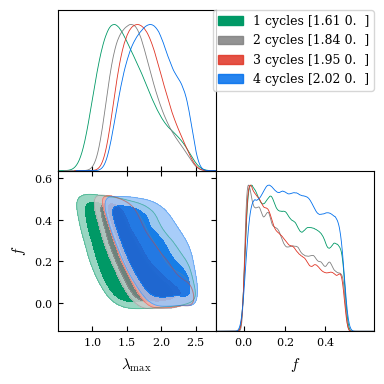

In [227]:
names = ["lambda_max", "f"]
labels = [r"\lambda_{\rm max}", r"f"]
output_name = f"{chain_path}/chebyshev1_source_{source}_Npre{param['Npre']}_Npost{param['Npost']}.png"
title = fr"$\mathrm{{Chebyshev~1st}}$ $[N_{{\rm pre}}={param['Npre']}, N_{{\rm post}} = {param['Npost']}]$"
plot_posterior(output_name, title, names, labels, names, sampler_c1 )

# Chebyshev 4th

[n_cycles=1] bestfit = [1.15847289 0.25      ], res0 = 2.348e-03
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 9      | 1        | 4        | 14100    | N/A    | 10074 | -1.64    
[n_cycles=2] bestfit = [1.34671231 0.25      ], res0 = 3.853e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 10     | 1        | 4        | 14800    | N/A    | 10092 | -2.33    
[n_cycles=3] bestfit = [1.4945349 0.25     ], res0 = 9.320e-05
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 10     | 1        | 4        | 15300    | N/A    | 10033 | -2.47    
[n_cycles=4] bestfit = [1.51619263 0.25      ], res

/local/home/mb280636/pysco/pysco/laplacian.py:1417: RuntimeWarning: overflow encountered in multiply
  z = np.float32(alpha[0]*Dm1) * r


Finished  | 10     | 1        | 4        | 15700    | N/A    | 10034 | -2.70    
idx=np.int64(30) meta['w'][idx]=1.25


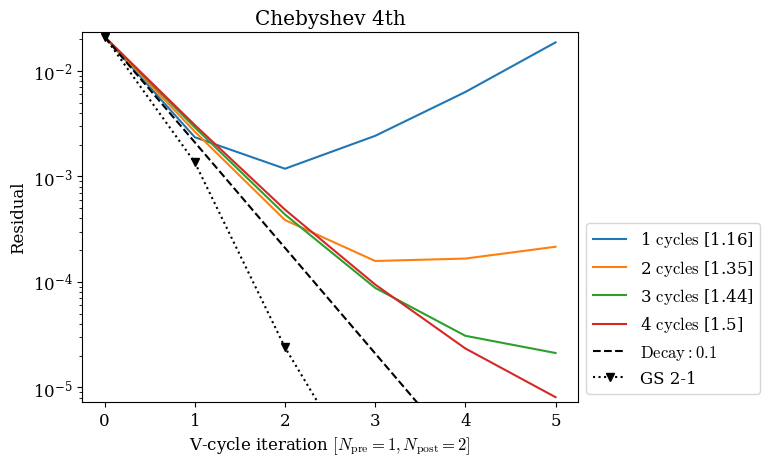

In [228]:
param_names = ["lambda_max", "f"]
priors = np.array([[0,2.5],
                   [0,0.5]])
guess = np.mean(priors, axis=1)
prior = make_nautilus_priors(param_names, priors)

# -------------------------------------------------
# Core residual evaluator
# -------------------------------------------------
def compute_residual(theta, n_cycles):
    x = x0.copy()
    lambda_max = float(theta[0])
    for _ in range(n_cycles):
        V_cycle_chebyshev4(x, b, param, lambda_max)
    return residual_error(x, b)
# -------------------------------------------------
# Main loop over iteration count
# -------------------------------------------------
sampler_c4 = run_fitting(niter, guess, priors, prior, residual)

# -------------------------------------------------
# Compute residual for bestfit parameters
# -------------------------------------------------
title = "Chebyshev 4th"
nparam = 1
plot_bestfit(param, title, nparam, sampler_c4)

[1.15824139]
Removed no burn in
[1.34692744]
Removed no burn in
[1.44478784]
Removed no burn in
[1.50070639]
Removed no burn in


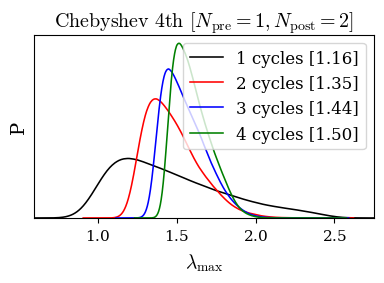

In [229]:
names = ["lambda_max", "f"]
labels = [r"\lambda_{\rm max}", r"f"]
plot_names = ["lambda_max"]
output_name = f"{chain_path}/chebyshev4_source_{source}_Npre{param['Npre']}_Npost{param['Npost']}.png"
title = fr"$\mathrm{{Chebyshev~4th}}$ $[N_{{\rm pre}}={param['Npre']}, N_{{\rm post}} = {param['Npost']}]$"
plot_posterior(output_name, title, names, labels, plot_names, sampler_c4 )

# Chebyshev 4th (Opt)

[n_cycles=1] bestfit = [1.27623742 0.25      ], res0 = 2.552e-03
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 8      | 1        | 4        | 14700    | N/A    | 10065 | -1.43    
[n_cycles=2] bestfit = [1.48062388 0.25      ], res0 = 3.749e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 9      | 1        | 4        | 14900    | N/A    | 10048 | -2.17    
[n_cycles=3] bestfit = [1.58046168 0.25      ], res0 = 9.205e-05
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 10     | 1        | 4        | 14900    | N/A    | 10101 | -2.36    
[n_cycles=4] bestfit = [1.62860455 0.25      ], r

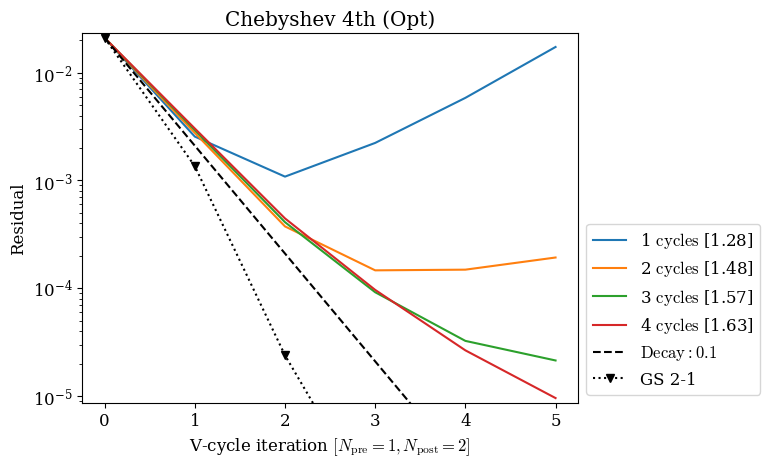

In [230]:
param_names = ["lambda_max", "f"]
priors = np.array([[0,2.5],
                   [0,0.5]])
guess = np.mean(priors, axis=1)
prior = make_nautilus_priors(param_names, priors)

# -------------------------------------------------
# Core residual evaluator
# -------------------------------------------------
def compute_residual(theta, n_cycles):
    x = x0.copy()
    lambda_max = float(theta[0])
    for _ in range(n_cycles):
        V_cycle_chebyshev4_opt(x, b, param, lambda_max)
    return residual_error(x, b)
# -------------------------------------------------
# Main loop over iteration count
# -------------------------------------------------
sampler_c4o = run_fitting(niter, guess, priors, prior, residual)

# -------------------------------------------------
# Compute residual for bestfit parameters
# -------------------------------------------------
title = "Chebyshev 4th (Opt)"
nparam = 1
plot_bestfit(param, title, nparam, sampler_c4o)

[1.27638309]
Removed no burn in
[1.47575013]
Removed no burn in
[1.57211948]
Removed no burn in
[1.62590702]
Removed no burn in


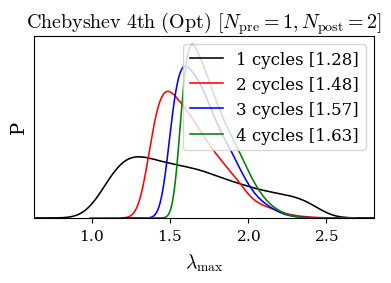

In [231]:
names = ["lambda_max", "f"]
labels = [r"\lambda_{\rm max}", r"f"]
plot_names = ["lambda_max"]
output_name = f"{chain_path}/chebyshev4_opt_source_{source}_Npre{param['Npre']}_Npost{param['Npost']}.png"
title = fr"$\mathrm{{Chebyshev~4th~(Opt)}}$ $[N_{{\rm pre}}={param['Npre']}, N_{{\rm post}} = {param['Npost']}]$"
plot_posterior(output_name, title, names, labels, plot_names, sampler_c4o )

# Chebyshev 1st - Jacobi

[n_cycles=1] bestfit = [0.70887719 0.12051458 0.94114297], res0 = 1.548e-03
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 10     | 1        | 4        | 15000    | N/A    | 10085 | -2.76    
[n_cycles=2] bestfit = [1.28902238 0.47140113 1.22706204], res0 = 6.694e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 9      | 1        | 4        | 15200    | N/A    | 10011 | -1.88    
[n_cycles=3] bestfit = [1.36124843 0.48833485 1.17730108], res0 = 1.844e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 10     | 1        | 4        | 15900    | N/A    | 10088 | -2.17    
[n_cycles=4] bes

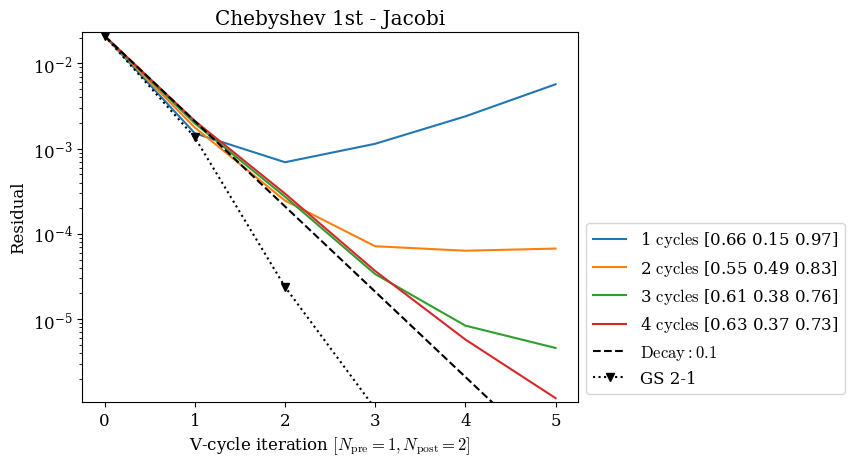

In [232]:
param_names = ["lambda_max", "f", "w"]
priors = np.array([[0,2.5],
                   [0,0.5],
                   [0,2.5]])
guess = np.mean(priors, axis=1)
prior = make_nautilus_priors(param_names, priors)

# -------------------------------------------------
# Core residual evaluator
# -------------------------------------------------
def compute_residual(theta, n_cycles):
    x = x0.copy()
    lambda_max = float(theta[0])
    lambda_min = float(theta[1])*lambda_max
    w = float(theta[2])
    for _ in range(n_cycles):
        V_cycle_chebyshev1_jacobi(x, b, param, lambda_min, lambda_max, w)
    return residual_error(x, b)
# -------------------------------------------------
# Main loop over iteration count
# -------------------------------------------------
sampler_c1j = run_fitting(niter, guess, priors, prior, residual)

# -------------------------------------------------
# Compute residual for bestfit parameters
# -------------------------------------------------
title = "Chebyshev 1st - Jacobi"
nparam = 3
plot_bestfit(param, title, nparam, sampler_c1j)

[0.65955054 0.15438089 0.97330786]
Removed no burn in
[0.55221859 0.48841119 0.83089279]
Removed no burn in
[0.61302876 0.37642074 0.76418009]
Removed no burn in
[0.63423901 0.37035372 0.73318977]
Removed no burn in


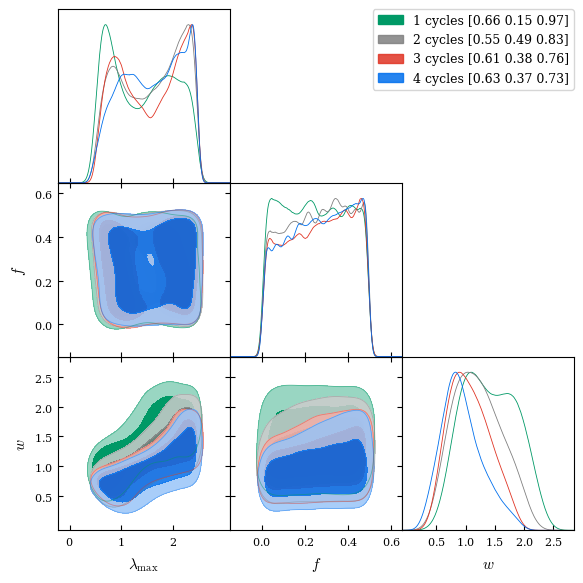

In [233]:
names = ["lambda_max", "f", "w"]
labels = [r"\lambda_{\rm max}", r"f", r"w"]
output_name = f"{chain_path}/chebyshev1-jacobi_source_{source}_Npre{param['Npre']}_Npost{param['Npost']}.png"
title = fr"$\mathrm{{Chebyshev~1st-Jacobi}}$ $[N_{{\rm pre}}={param['Npre']}, N_{{\rm post}} = {param['Npost']}]$"
plot_posterior(output_name, title, names, labels, names, sampler_c1j )

# Chebyshev 1st - Gauss-Seidel

[n_cycles=1] bestfit = [0.63871067 0.09502343 1.22973274], res0 = 1.522e-03
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 11     | 1        | 4        | 15200    | N/A    | 10110 | -3.10    
[n_cycles=2] bestfit = [2.49637994 0.49628146 1.33588641], res0 = 3.412e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 10     | 1        | 4        | 15300    | N/A    | 10027 | -2.68    
[n_cycles=3] bestfit = [2.25556853 0.46966135 1.38637305], res0 = 4.896e-05
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 11     | 1        | 4        | 16100    | N/A    | 10058 | -3.34    
[n_cycles=4] bes

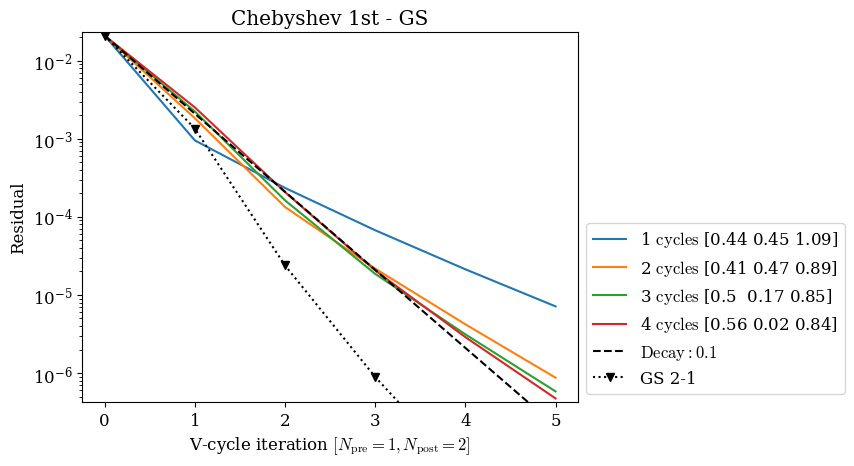

In [234]:
param_names = ["lambda_max", "f", "w"]
priors = np.array([[0,2.5],
                   [0,0.5],
                   [0,2.5]])
guess = np.mean(priors, axis=1)
prior = make_nautilus_priors(param_names, priors)

# -------------------------------------------------
# Core residual evaluator
# -------------------------------------------------
def compute_residual(theta, n_cycles):
    x = x0.copy()
    lambda_max = float(theta[0])
    lambda_min = float(theta[1])*lambda_max
    w = float(theta[2])
    for _ in range(n_cycles):
        V_cycle_chebyshev1_gs(x, b, param, lambda_min, lambda_max, w)
    return residual_error(x, b)
# -------------------------------------------------
# Main loop over iteration count
# -------------------------------------------------
sampler_c1g = run_fitting(niter, guess, priors, prior, residual)

# -------------------------------------------------
# Compute residual for bestfit parameters
# -------------------------------------------------
title = "Chebyshev 1st - GS"
nparam = 3
plot_bestfit(param, title, nparam, sampler_c1g)

[0.43627127 0.44882171 1.08613655]
Removed no burn in
[0.40845325 0.4680144  0.89182494]
Removed no burn in
[0.49965194 0.16884726 0.85361171]
Removed no burn in
[0.56064279 0.01703442 0.83656378]
Removed no burn in


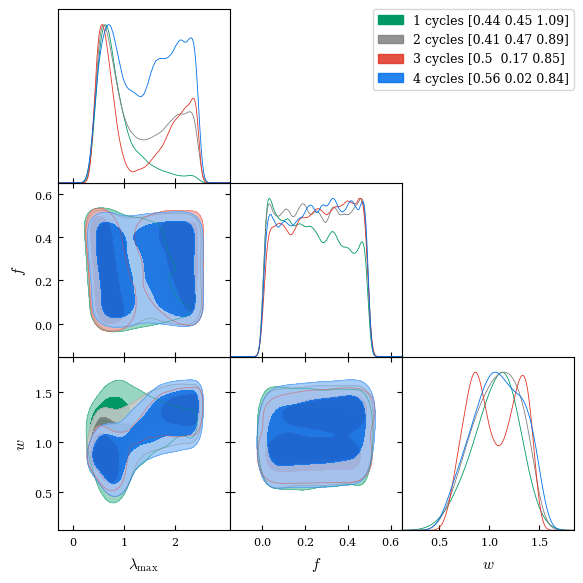

In [235]:
names = ["lambda_max", "f", "w"]
labels = [r"\lambda_{\rm max}", r"f", r"w"]
output_name = f"{chain_path}/chebyshev1-gs_source_{source}_Npre{param['Npre']}_Npost{param['Npost']}.png"
title = fr"$\mathrm{{Chebyshev~1st-GS}}$ $[N_{{\rm pre}}={param['Npre']}, N_{{\rm post}} = {param['Npost']}]$"
plot_posterior(output_name, title, names, labels, names, sampler_c1g )

# Chebyshev 4th - Jacobi

[n_cycles=1] bestfit = [1.17034143 1.30197382], res0 = 3.047e-03
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 8      | 1        | 4        | 14200    | N/A    | 10008 | -1.23    
[n_cycles=2] bestfit = [1.3253119  1.29037758], res0 = 6.617e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 9      | 1        | 4        | 15300    | N/A    | 10014 | -1.83    
[n_cycles=3] bestfit = [1.48669703 1.24580822], res0 = 1.746e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 10     | 1        | 4        | 15400    | N/A    | 10021 | -2.10    
[n_cycles=4] bestfit = [1.5053339  1.19060742], r

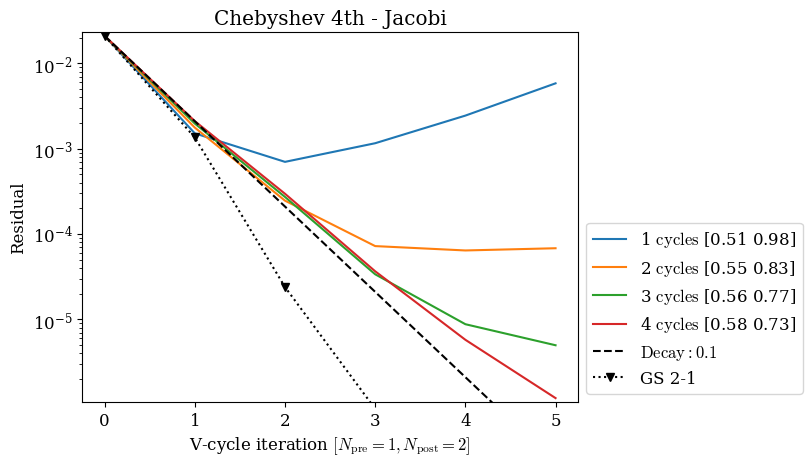

In [236]:
param_names = ["lambda_max", "w"]
priors = np.array([[0,2.5],
                   [0,2.5]])
guess = np.mean(priors, axis=1)
prior = make_nautilus_priors(param_names, priors)

# -------------------------------------------------
# Core residual evaluator
# -------------------------------------------------
def compute_residual(theta, n_cycles):
    x = x0.copy()
    lambda_max = float(theta[0])
    w = float(theta[1])
    for _ in range(n_cycles):
        V_cycle_chebyshev4_jacobi(x, b, param, lambda_max, w)
    return residual_error(x, b)
# -------------------------------------------------
# Main loop over iteration count
# -------------------------------------------------
sampler_c4j = run_fitting(niter, guess, priors, prior, residual)

# -------------------------------------------------
# Compute residual for bestfit parameters
# -------------------------------------------------
title = "Chebyshev 4th - Jacobi"
nparam = 2
plot_bestfit(param, title, nparam, sampler_c4j)

[0.50925376 0.97535467]
Removed no burn in
[0.54891181 0.83162324]
Removed no burn in
[0.56201313 0.76592342]
Removed no burn in
[0.5769242  0.73292951]
Removed no burn in


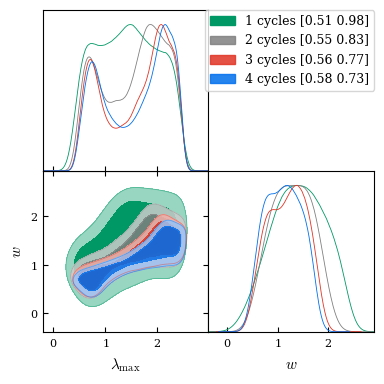

In [237]:
names = ["lambda_max", "w"]
labels = [r"\lambda_{\rm max}", r"w"]
output_name = f"{chain_path}/chebyshev4-jacobi_source_{source}_Npre{param['Npre']}_Npost{param['Npost']}.png"
title = fr"$\mathrm{{Chebyshev~4th-Jacobi}}$ $[N_{{\rm pre}}={param['Npre']}, N_{{\rm post}} = {param['Npost']}]$"
plot_posterior(output_name, title, names, labels, names, sampler_c4j )

# Chebyshev 4th - Gauss-Seidel

[n_cycles=1] bestfit = [0.40802952 1.11875376], res0 = 9.900e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 13     | 1        | 4        | 16500    | N/A    | 10036 | -4.60    
[n_cycles=2] bestfit = [1.69354081 1.22234387], res0 = 4.818e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 10     | 1        | 4        | 15200    | N/A    | 10072 | -2.03    
[n_cycles=3] bestfit = [2.25116094 1.38753995], res0 = 4.882e-05
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 11     | 1        | 4        | 15900    | N/A    | 10034 | -3.23    
[n_cycles=4] bestfit = [1.25239299 1.19062026], r

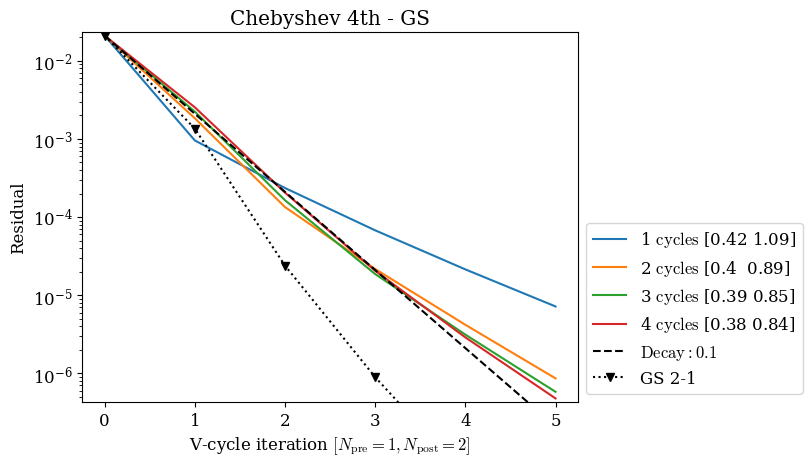

In [238]:
param_names = ["lambda_max", "w"]
priors = np.array([[0,2.5],
                   [0,2.5]])
guess = np.mean(priors, axis=1)
prior = make_nautilus_priors(param_names, priors)

# -------------------------------------------------
# Core residual evaluator
# -------------------------------------------------
def compute_residual(theta, n_cycles):
    x = x0.copy()
    lambda_max = float(theta[0])
    w = float(theta[1])
    for _ in range(n_cycles):
        V_cycle_chebyshev4_gs(x, b, param, lambda_max, w)
    return residual_error(x, b)
# -------------------------------------------------
# Main loop over iteration count
# -------------------------------------------------
sampler_c4g = run_fitting(niter, guess, priors, prior, residual)

# -------------------------------------------------
# Compute residual for bestfit parameters
# -------------------------------------------------
title = "Chebyshev 4th - GS"
nparam = 2
plot_bestfit(param, title, nparam, sampler_c4g)

[0.42156376 1.08639704]
Removed no burn in
[0.40105128 0.88939776]
Removed no burn in
[0.39063685 0.85221239]
Removed no burn in
[0.37872049 0.83849225]
Removed no burn in


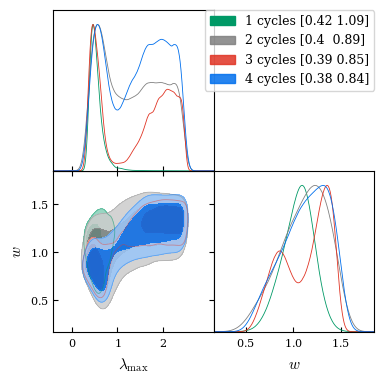

In [239]:
names = ["lambda_max", "w"]
labels = [r"\lambda_{\rm max}", r"w"]
output_name = f"{chain_path}/chebyshev4-gs_source_{source}_Npre{param['Npre']}_Npost{param['Npost']}.png"
title = fr"$\mathrm{{Chebyshev~4th-GS}}$ $[N_{{\rm pre}}={param['Npre']}, N_{{\rm post}} = {param['Npost']}]$"
plot_posterior(output_name, title, names, labels, names, sampler_c4g )

# Chebyshev 4th (Opt) - Jacobi

[n_cycles=1] bestfit = [0.72365676 0.99775559], res0 = 2.087e-03
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 9      | 1        | 4        | 14200    | N/A    | 10103 | -1.94    
[n_cycles=2] bestfit = [1.31460117 1.18913417], res0 = 6.870e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 9      | 1        | 4        | 15200    | N/A    | 10084 | -1.83    
[n_cycles=3] bestfit = [1.33185481 1.1959061 ], res0 = 3.381e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 9      | 1        | 4        | 15400    | N/A    | 10031 | -1.59    
[n_cycles=4] bestfit = [1.8466221 0.9346942], res

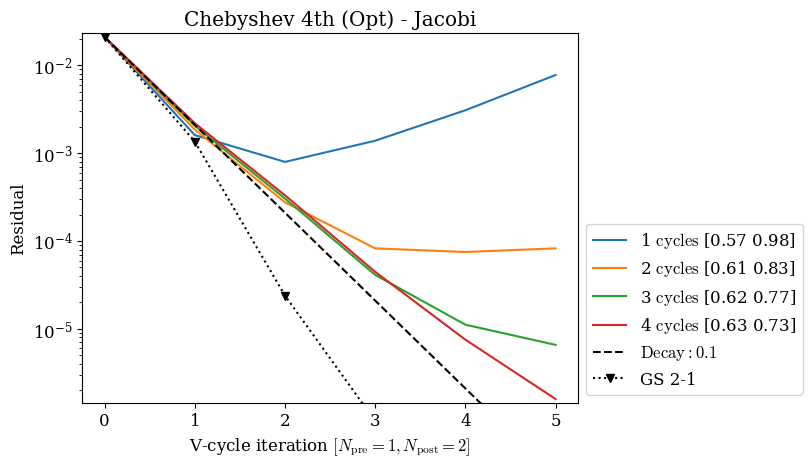

In [240]:
param_names = ["lambda_max", "w"]
priors = np.array([[0,2.5],
                   [0,2.5]])
guess = np.mean(priors, axis=1)
prior = make_nautilus_priors(param_names, priors)

# -------------------------------------------------
# Core residual evaluator
# -------------------------------------------------
def compute_residual(theta, n_cycles):
    x = x0.copy()
    lambda_max = float(theta[0])
    w = float(theta[1])
    for _ in range(n_cycles):
        V_cycle_chebyshev4_opt_jacobi(x, b, param, lambda_max, w)
    return residual_error(x, b)
# -------------------------------------------------
# Main loop over iteration count
# -------------------------------------------------
sampler_c4oj = run_fitting(niter, guess, priors, prior, residual)

# -------------------------------------------------
# Compute residual for bestfit parameters
# -------------------------------------------------
title = "Chebyshev 4th (Opt) - Jacobi"
nparam = 2
plot_bestfit(param, title, nparam, sampler_c4oj)

[0.56574725 0.98432779]
Removed no burn in
[0.60680387 0.83399512]
Removed no burn in
[0.61931885 0.76937089]
Removed no burn in
[0.63484825 0.73432104]
Removed no burn in


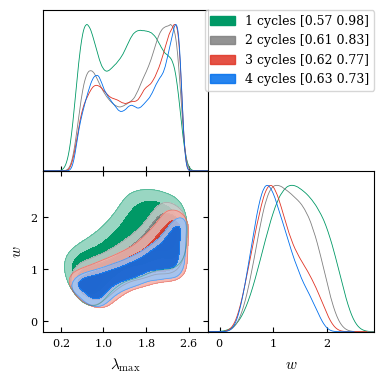

In [241]:
names = ["lambda_max", "w"]
labels = [r"\lambda_{\rm max}", r"w"]
output_name = f"{chain_path}/chebyshev4_opt-jacobi_source_{source}_Npre{param['Npre']}_Npost{param['Npost']}.png"
title = fr"$\mathrm{{Chebyshev~4th~(Opt)-Jacobi}}$ $[N_{{\rm pre}}={param['Npre']}, N_{{\rm post}} = {param['Npost']}]$"
plot_posterior(output_name, title, names, labels, names, sampler_c4oj )

# Chebyshev 4th (Opt) - Gauss-Seidel

[n_cycles=1] bestfit = [0.51284738 1.13296731], res0 = 1.166e-03
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 12     | 1        | 4        | 15700    | N/A    | 10078 | -4.04    
[n_cycles=2] bestfit = [2.46936659 1.35293376], res0 = 3.581e-04
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 10     | 1        | 4        | 15200    | N/A    | 10083 | -2.60    
[n_cycles=3] bestfit = [2.37579244 1.40656261], res0 = 5.239e-05
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 11     | 1        | 4        | 16000    | N/A    | 10093 | -3.26    
[n_cycles=4] bestfit = [1.89425281 1.44154914], r

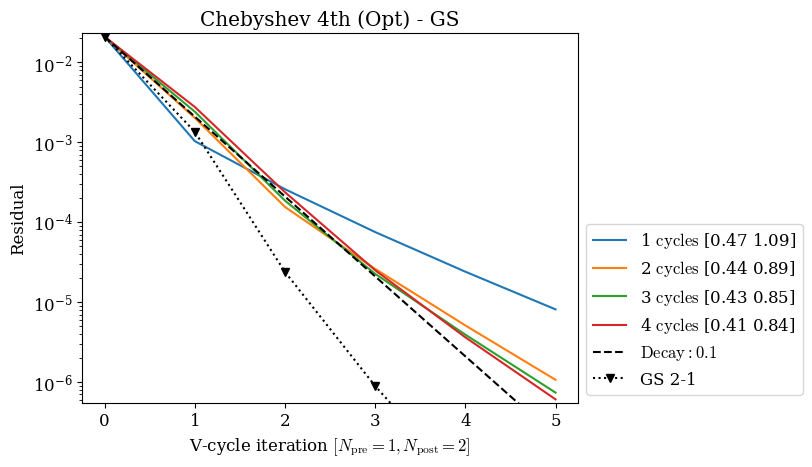

In [242]:
param_names = ["lambda_max", "w"]
priors = np.array([[0,2.5],
                   [0,2.5]])
guess = np.mean(priors, axis=1)
prior = make_nautilus_priors(param_names, priors)

# -------------------------------------------------
# Core residual evaluator
# -------------------------------------------------
def compute_residual(theta, n_cycles):
    x = x0.copy()
    lambda_max = float(theta[0])
    w = float(theta[1])
    for _ in range(n_cycles):
        V_cycle_chebyshev4_opt_gs(x, b, param, lambda_max, w)
    return residual_error(x, b)
# -------------------------------------------------
# Main loop over iteration count
# -------------------------------------------------
sampler_c4og = run_fitting(niter, guess, priors, prior, residual)

# -------------------------------------------------
# Compute residual for bestfit parameters
# -------------------------------------------------
title = "Chebyshev 4th (Opt) - GS"
nparam = 2
plot_bestfit(param, title, nparam, sampler_c4og)

[0.46942132 1.0906041 ]
Removed no burn in
[0.43550076 0.89303236]
Removed no burn in
[0.42693936 0.85398966]
Removed no burn in
[0.4124757  0.83851781]
Removed no burn in


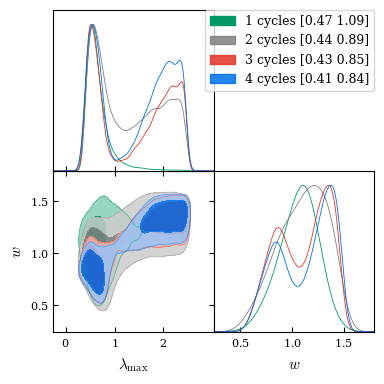

In [243]:
names = ["lambda_max", "w"]
labels = [r"\lambda_{\rm max}", r"w"]
output_name = f"{chain_path}/chebyshev4_opt-gs_source_{source}_Npre{param['Npre']}_Npost{param['Npost']}.png"
title = fr"$\mathrm{{Chebyshev~4th~(Opt)-GS}}$ $[N_{{\rm pre}}={param['Npre']}, N_{{\rm post}} = {param['Npost']}]$"
plot_posterior(output_name, title, names, labels, names, sampler_c4og )